[Uniform GRID] Nr=30, Nz=334, N=10020 (target 10000)

=== YHP PINN: Re=196, delta_rough=0.12, r_train=0.25 ===
[PLOT SAVED] YHP_NEW_TRY\REF_Anchors_Re196_a0.12_r0.25_clean_nobs30_ndense200.png
  X_obs shape: (30, 2)
  z range     : 0.0 → 10.0
  U min/max   : -1.0587913576172746e-23 → 0.039890870451927185
  V min/max   : -0.25 → -1.0111455631143368e-22
  W min/max   : -0.930907130241394 → 3.2884963332715406e-19
[REF] U'_ref(0)=3.87035851e-01, V'_ref(0)=-5.17814016e-01
Compiling model...
'compile' took 0.000172 s

Training model...

Step      Train loss                                                                                                                                      Test loss                                                                                                                                       Test metric
0         [1.14e-03, 2.68e-05, 1.12e-04, 4.90e-09, 3.71e-02, 2.74e-02, 6.50e-01, 4.40e-07, 2.31e-06, 6.05e-09, 3.37e-05, 1.15e-05, 6.12e-02, 4.80e-01]   

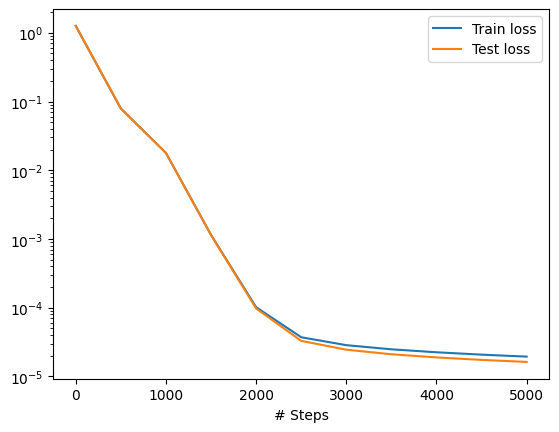

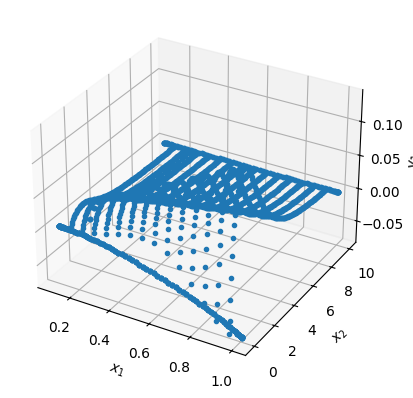

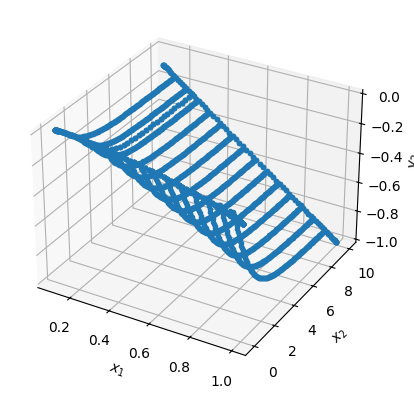

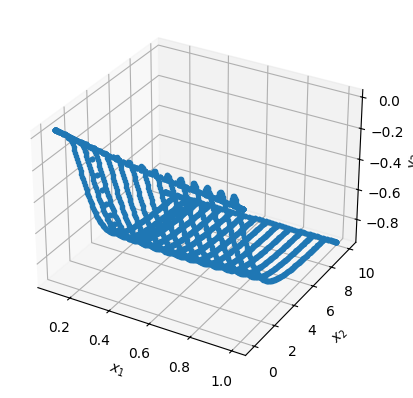

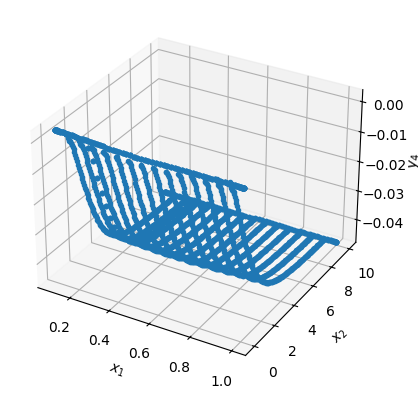

r_train=0.25, r_eval=0.25 | E_U=2.293663e-02, E_V=2.845441e-03, E_W=3.154588e-03, u_prime=0.094958, v_prime=-0.131316, w_r_eval_zL=-0.934859, Rel_U=7.660673e+02, Rel_V=2.296981e+02, Rel_W=4.323031e+01
r_train=0.25, r_eval=0.75 | E_U=1.169772e-01, E_V=2.954878e-02, E_W=2.401051e-02, u_prime=0.292622, v_prime=-0.389367, w_r_eval_zL=-0.934848, Rel_U=2.054493e+04, Rel_V=6.425654e+04, Rel_W=4.458091e+04
r_train=0.25, r_eval=0.85 | E_U=2.191311e-01, E_V=2.897337e-02, E_W=2.160421e-02, u_prime=-0.078008, v_prime=-0.580400, w_r_eval_zL=-0.934694, Rel_U=3.258603e+04, Rel_V=6.703071e+04, Rel_W=4.247449e+04
r_train=0.25, r_eval=1.00 | E_U=3.075340e-01, E_V=3.464501e-02, E_W=2.529233e-02, u_prime=-0.308305, v_prime=-0.714809, w_r_eval_zL=-0.934561, Rel_U=3.819243e+04, Rel_V=8.194123e+04, Rel_W=4.432844e+04


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import math

import torch
import torch_directml
import deepxde as dde
import csv

# =====================================================
# 1) YHP SİSTEMİ: von Kármán + roughness (nord, delta_rough)
# =====================================================

def s_function(delta_rough, gamma, r, nord):
    """MATLAB s_function: RAW yüzey fonksiyonu (ölçeklenmemiş)."""
    r = np.asarray(r, dtype=float)
    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)

    for k in range(1, nord + 1):
        d = ((-1) ** k) * (1.0 / k)
        arg = 2.0 * np.pi * r * k / gamma
        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * ((2.0 * np.pi * k / gamma) ** 2)

    return s, sp, spp


def amplitude(gamma, delta_rough, nord):
    x = np.linspace(0.0, gamma, 500)
    s, _, _ = s_function(delta_rough, gamma, x, nord)
    return np.max(s)


def s_scaled(delta_rough, gamma, r, nord, max_s):
    s, sp, spp = s_function(delta_rough, gamma, r, nord)
    if max_s != 0.0:
        factor = delta_rough / max_s
    else:
        factor = 0.0
    s *= factor
    sp *= factor
    spp *= factor
    return s, sp, spp


def karmanode(x, y):
    """
    VK ODE sistemi.
    y[0]=f, y[1]=g, y[2]=h, y[3]=f', y[4]=g'
    """
    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    uprime = f * f - (g + 1.0) * (g + 1.0) + h * df
    vprime = 2.0 * f * (g + 1.0) + h * dg

    dy_dx = np.vstack((
        df,          # f'
        dg,          # g'
        -2.0 * f,    # h'
        uprime,      # f''
        vprime       # g''
    ))
    return dy_dx


def karmanbc(ya, yb):
    """
    BC: f(0)=0, g(0)=0, h(0)=0, f(∞)=0, g(∞)=-1
    """
    return np.array([
        ya[0],
        ya[1],
        ya[2],
        yb[0],
        yb[1] + 1.0,
    ])


def karmanpde2(x, y, fr, gr, hr, dfr, dgr, xr,
               delta_rough, gamma, r, dr, nord, max_s):
    """
    YHP marching ODE sistemi.
    """
    # Önceki adım çözümünden interpolasyon
    f1 = np.interp(x, xr, fr)
    g1 = np.interp(x, xr, gr)
    h1 = np.interp(x, xr, hr)
    # dfr, dgr de interpolanıyor ama denklemlerde kullanılmıyor:
    df1 = np.interp(x, xr, dfr)
    dg1 = np.interp(x, xr, dgr)

    # Roughness yüzeyi (r sabit)
    s, sp, spp = s_scaled(delta_rough, gamma, r, nord, max_s)

    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    # Denklemler
    eq1 = -2.0 * f1 - r * (f - f1) / dr

    term1_2 = r * f1 * (f - f1) / dr
    term2_2 = h1 * df
    term3_2 = (1.0 + (r - dr) * sp * spp / (1.0 + sp**2)) * (f1**2)
    term4_2 = (1.0 + g1)**2 / (1.0 + sp**2)
    term5 = 1.0 + sp**2
    eq2 = (term1_2 + term2_2 + term3_2 - term4_2) / term5

    term1_3 = r * f1 * (g - g1) / dr
    term2_3 = h1 * dg
    term3_3 = 2.0 * f1 * (1.0 + g1)
    eq3 = (term1_3 + term2_3 + term3_3) / term5

    dy_dx = np.vstack((
        df,   # y1' = y4
        dg,   # y2' = y5
        eq1,  # y3'
        eq2,  # y4'
        eq3   # y5'
    ))
    return dy_dx


def solve_yhp_mean_profiles(delta_rough, nord,
                            upper_z=10.0, gamma=1.0, nmax=100):
    """
    Tek bir delta_rough ve nord için YHP mean-flow profillerini (fbar,gbar,hbar) çözer.
    Geri dönüş: eta_grid, fbar, gbar, hbar
    """
    max_s = amplitude(gamma, delta_rough, nord)
    dr = gamma / nmax

    # Base VK (smooth) ile seed
    z_mesh = np.linspace(0.0, upper_z, 100)
    y_init = np.zeros((5, z_mesh.size))
    y_init[0, :] = 0.1   # f
    y_init[1, :] = -1.0  # g
    y_init[2, :] = -1.0  # h
    y_init[3, :] = 0.0   # f'
    y_init[4, :] = 0.0   # g'

    sol = solve_bvp(karmanode, karmanbc, z_mesh, y_init,
                    tol=1e-8, max_nodes=10000)
    if sol.status != 0:
        print("UYARI: base-flow BVP yakınsamadı, status =", sol.status)

    xvK = np.linspace(0.0, upper_z, 2000)
    yvK = sol.sol(xvK)
    fr = yvK[0, :]
    gr = yvK[1, :]
    hr = yvK[2, :]
    dfr = yvK[3, :]
    dgr = yvK[4, :]
    xr = xvK

    fall = []
    gall = []
    hall = []
    dfall = []
    dgall = []

    for n in range(1, nmax + 1):
        r = n * dr
        y_init_n = np.vstack((fr, gr, hr, dfr, dgr))
        sol_n = solve_bvp(
            lambda x, y: karmanpde2(
                x, y, fr, gr, hr, dfr, dgr, xr,
                delta_rough, gamma, r, dr, nord, max_s
            ),
            karmanbc,
            xr,
            y_init_n,
            tol=1e-8,
            max_nodes=10000
        )
        if sol_n.status != 0:
            print(f"  UYARI: n={n} adımında BVP yakınsamadı, status={sol_n.status}")

        y_n = sol_n.sol(xr)
        fr = y_n[0, :]
        gr = y_n[1, :]
        hr = y_n[2, :]
        dfr = y_n[3, :]
        dgr = y_n[4, :]

        fall.append(fr)
        gall.append(gr)
        hall.append(hr)
        dfall.append(dfr)
        dgall.append(dgr)

    fall = np.array(fall)
    gall = np.array(gall)
    hall = np.array(hall)

    fbar = fall.mean(axis=0)
    gbar = gall.mean(axis=0)
    hbar = hall.mean(axis=0)

    return xr, fbar, gbar, hbar  # xr burada η-grid (0..upper_z)

def forward_diff_at_0(y: np.ndarray, x: np.ndarray) -> float:
    """
    Uniform grid x üzerinde, y(x) için x=0 noktasındaki türevi ileri farkla hesaplar.
    5 nokta varsa 4. mertebe, 3 nokta varsa 2. mertebe, aksi halde 1. mertebe.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if y.size < 2:
        raise ValueError("Türev için en az 2 nokta gerekli.")
    h = x[1] - x[0]
    if y.size >= 5:
        return float((-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h))
    elif y.size >= 3:
        return float((-3*y[0] + 4*y[1] - y[2]) / (2*h))
    else:
        return float((y[1] - y[0]) / h)
    
def finite_diff_deta_at_wall(model, r0: float, h: float = 1e-4):
    """
    r=r0 için eta=0'da u_eta ve v_eta'yı ileri farkla yaklaşıkla.
    (eta domaininde: z ile aynı doğrultuda olduğundan duvar shear için uygun.)
    """
    X0 = np.array([[r0, 0.0]], dtype=np.float32)
    Xh = np.array([[r0, h]], dtype=np.float32)

    y0 = model.predict(X0)  # [u,v,w,p]
    yh = model.predict(Xh)

    u_eta = (yh[0, 0] - y0[0, 0]) / h
    v_eta = (yh[0, 1] - y0[0, 1]) / h
    return float(u_eta), float(v_eta)
    


def generate_obs_profiles_from_yhp(Re, delta_rough, nord,
                                   r_obs, L,
                                   n_z_obs=10,           # seçilecek nokta sayısı (plot/BC)
                                   n_z_dense=200,        # dense profil çözünürlüğü
                                   upper_z=10.0, gamma=1.0, nmax=100):
    """
    YHP mean-flow'dan r=r_obs için U,V,W profillerini üret.

    Çıkış:
      - (X_obs, U_obs, V_obs, W_obs, z_obs): dense profilden seçilmiş n_z_obs nokta
      - (X_dense, U_dense, V_dense, W_dense, z_dense): dense profil (grafik için)
      - (u_num, v_num, w_num): referanstan türetilen kritik değerler

    Not: Senin kurguya göre referans zaten BL-scale (η-uzayı). Bu nedenle z eksenini η gibi kullanıyoruz:
         eta = z
    """
    eta_grid, fbar, gbar, hbar = solve_yhp_mean_profiles(
        delta_rough, nord, upper_z=upper_z, gamma=gamma, nmax=nmax
    )

    # --- dense z/eta çizgisi ---
    z_dense = np.linspace(0.0, L, n_z_dense).astype(np.float64)   # (Nz_dense,)
    # eta_dense (reference param)
    eta_dense = np.linspace(0.0, L, n_z_dense).astype(np.float64)
    delta_Re = Re ** (-0.5)

    # fiziksel z
    z_dense = (eta_dense).astype(np.float64)

    # mean profilleri eta_dense üzerinden üret (z değil!)
    eta_dense_clipped = np.clip(eta_dense, eta_grid[0], eta_grid[-1])
    f_dense = np.interp(eta_dense_clipped, eta_grid, fbar)
    g_dense = np.interp(eta_dense_clipped, eta_grid, gbar)
    h_dense = np.interp(eta_dense_clipped, eta_grid, hbar)

    U_dense = (r_obs * f_dense).reshape(-1,1).astype(np.float32)
    V_dense = (r_obs * g_dense).reshape(-1,1).astype(np.float32)
    W_dense = (h_dense).reshape(-1,1).astype(np.float32)

    X_dense = np.column_stack([r_obs*np.ones_like(z_dense), z_dense]).astype(np.float32)
    z_dense_col = z_dense.reshape(-1,1).astype(np.float32)

    # obs indekslerini yeni boyuta göre seç
    idx = np.linspace(0, len(z_dense)-1, n_z_obs, dtype=int)
    X_obs = X_dense[idx,:]
    U_obs = U_dense[idx,:]
    V_obs = V_dense[idx,:]
    W_obs = W_dense[idx,:]
    z_obs = z_dense_col[idx,:]

    # --- referanstan sayısal hedefler ---
    # u_num = f'(0), v_num = g'(0) (eta uzayında)
    u_num = forward_diff_at_0(fbar, eta_grid)
    v_num = forward_diff_at_0(gbar, eta_grid)

    # w_num: L'de h(L) (dense ile tutarlı)
    w_num = float(W_dense[-1, 0])

    return (X_obs, U_obs, V_obs, W_obs, z_obs,
            X_dense, U_dense, V_dense, W_dense, z_dense_col,
            float(u_num), float(v_num), float(w_num))

def save_reference_and_anchors_plot(
    base_dir: str,
    Re: float,
    a_amp: float,
    r_obs: float,
    L: float,
    z_dense_col: np.ndarray,
    U_dense_ref: np.ndarray,
    V_dense_ref: np.ndarray,
    W_dense_ref: np.ndarray,
    X_obs: np.ndarray,
    U_obs: np.ndarray,
    V_obs: np.ndarray,
    W_obs: np.ndarray,
    tag: str = "clean",
    dpi: int = 200,
):
    """
    Referans dense profilleri + anchor (obs) noktalarını çizip base_dir'e kaydeder.
    x-ekseni: eta (senin kodunda z_dense = eta kabulüyle).
    """

    os.makedirs(base_dir, exist_ok=True)

    z_dense = np.asarray(z_dense_col, dtype=float).reshape(-1)
    z_obs   = np.asarray(X_obs[:, 1], dtype=float).reshape(-1)

    eta_dense = z_dense 
    eta_obs   = z_obs   

    U_dense = np.asarray(U_dense_ref, dtype=float).reshape(-1)
    V_dense = np.asarray(V_dense_ref, dtype=float).reshape(-1)
    W_dense = np.asarray(W_dense_ref, dtype=float).reshape(-1)

    Uo = np.asarray(U_obs, dtype=float).reshape(-1)
    Vo = np.asarray(V_obs, dtype=float).reshape(-1)
    Wo = np.asarray(W_obs, dtype=float).reshape(-1)

    fig, axes = plt.subplots(3, 1, figsize=(7.5, 9.0), sharex=True)

    # --- U ---
    axes[0].plot(eta_dense, U_dense, label="Reference (dense)")
    axes[0].scatter(eta_obs, Uo, s=35, marker="o", label="Anchors (obs)")
    axes[0].set_ylabel(r"$u(r=%.2f,\eta)$" % r_obs)
    axes[0].grid(True)

    # --- V ---
    axes[1].plot(eta_dense, V_dense, label="Reference (dense)")
    axes[1].scatter(eta_obs, Vo, s=35, marker="o", label="Anchors (obs)")
    axes[1].set_ylabel(r"$v(r=%.2f,\eta)$" % r_obs)
    axes[1].grid(True)

    # --- W ---
    axes[2].plot(eta_dense, W_dense, label="Reference (dense)")
    axes[2].scatter(eta_obs, Wo, s=35, marker="o", label="Anchors (obs)")
    axes[2].set_ylabel(r"$w(r=%.2f,\eta)$" % r_obs)
    axes[2].set_xlabel(r"$\eta$")
    axes[2].grid(True)

    # başlık + legend
    fig.suptitle(f"YHP Reference + Anchors | Re={Re}, a={a_amp}, r={r_obs}, L={L} | {tag}", y=0.98)
    axes[0].legend(loc="best", fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_png = os.path.join(base_dir, f"REF_Anchors_Re{int(Re)}_a{a_amp}_r{r_obs}_{tag}.png")
    out_pdf = os.path.join(base_dir, f"REF_Anchors_Re{int(Re)}_a{a_amp}_r{r_obs}_{tag}.pdf")
    plt.savefig(out_png, dpi=dpi)
    plt.savefig(out_pdf)
    plt.close(fig)

    print("[PLOT SAVED]", out_png)


# =====================================================
# 2) PINN KISMI (YHP ile empoze edilmiş)
# =====================================================

device = torch_directml.device()
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)

Re_list = [196]
delta_rough_list = [0.12]  # YHP pürüz yükseklikleri
nord = 1  # YHP geometri mertebesi
r_train = 0.25
r_eval_list = [0.25, 0.75, 0.85, 1.00]

layer_sizes = [4]
neuron_sizes = [64]
L = 10.0
r_min = 0.1
r_max = 1.0
# Duvar tüm aralıkta negatif de olabileceği için geometriyi aşağı genişlet:
z_min = -float(np.max(np.abs(delta_rough_list)))
geom = dde.geometry.Rectangle([r_min, 0], [r_max, L])


def wall_height_np(r: np.ndarray, delta_rough: float) -> np.ndarray:
    r = np.asarray(r, dtype=float)
    return delta_rough * np.cos(2.0 * np.pi * r)

def wall_sprime_torch(r: torch.Tensor, delta_rough: float) -> torch.Tensor:
    # s'(r) = -delta*(2*pi)*sin(2*pi*r)
    return -delta_rough * (2.0 * math.pi) * torch.sin(2.0 * math.pi * r)

def build_wavy_wall_points(r_vals: np.ndarray, delta_rough: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_vals = (delta_rough * np.cos(2.0 * np.pi * r_vals)).astype(np.float32)
    return np.column_stack([r_vals, z_vals]).astype(np.float32)

def build_top_points(r_vals: np.ndarray, L: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_vals = np.full_like(r_vals, float(L), dtype=np.float32)
    return np.column_stack([r_vals, z_vals]).astype(np.float32)


def wall_height(r, delta_rough):
    # r: torch tensor (N,1)
    return delta_rough * torch.cos(2.0 * math.pi * r)

# ---------------------------
# Clenshaw–Curtis
# ---------------------------
def clenshaw_curtis_nodes_weights(N, a=-1.0, b=1.0):
    if N < 1:
        raise ValueError("N >= 1 olmalı.")
    k = np.arange(0, N + 1)
    x = np.cos(np.pi * k / N)
    w = np.zeros(N + 1, dtype=float)
    if N % 2 == 0:
        m = np.arange(1, N // 2)
        v = np.zeros_like(k, dtype=float)
        for j in m:
            v += (np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0))
        w = (2.0 / N) * (1.0 - v - (np.cos(np.pi * k) / (N * N - 1.0)))
    else:
        m = np.arange(1, (N + 1) // 2)
        v = np.zeros_like(k, dtype=float)
        for j in m:
            v += (np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0))
        w = (2.0 / N) * (1.0 - v)
    xm = 0.5 * (a + b) + 0.5 * (b - a) * x
    wm = 0.5 * (b - a) * w
    return xm, wm


N_r, N_z = 80, 256
R_nodes, W_r = clenshaw_curtis_nodes_weights(N_r, a=r_min, b=r_max)
Z_nodes, W_z = clenshaw_curtis_nodes_weights(N_z, a=0,   b=L)

RR, ZZ = np.meshgrid(R_nodes, Z_nodes, indexing="xy")
Wr, Wz = np.meshgrid(W_r,     W_z,     indexing="xy")
W2D = (Wr * Wz).reshape(-1, 1)

domain_cc = np.column_stack([RR.reshape(-1), ZZ.reshape(-1)]).astype(np.float32)

R_nodes_t = torch.tensor(R_nodes, dtype=torch.float32, device=device).view(1, -1)
Z_nodes_t = torch.tensor(Z_nodes, dtype=torch.float32, device=device).view(1, -1)
W_r_t     = torch.tensor(W_r,     dtype=torch.float32, device=device).view(1, -1)
W_z_t     = torch.tensor(W_z,     dtype=torch.float32, device=device).view(1, -1)


def cc_weight_rz(r, z):
    dist_r = torch.abs(r - R_nodes_t)
    idx_r  = torch.argmin(dist_r, dim=1, keepdim=True)
    dist_z = torch.abs(z - Z_nodes_t)
    idx_z  = torch.argmin(dist_z, dim=1, keepdim=True)
    w_r = torch.gather(W_r_t.repeat(r.shape[0], 1), 1, idx_r)
    w_z = torch.gather(W_z_t.repeat(z.shape[0], 1), 1, idx_z)
    return w_r * w_z

def cc_weight_r(r):
    # r: (N,1)
    dist_r = torch.abs(r - R_nodes_t)                 # (N, Nr+1)
    idx_r  = torch.argmin(dist_r, dim=1, keepdim=True)
    w_r = torch.gather(W_r_t.repeat(r.shape[0], 1), 1, idx_r)  # (N,1)
    return w_r

# ---------------------------
# PDE + BC'ler (YHP BC'leri ile)
# ---------------------------
def make_pde(Re, delta_rough):
    def pde(x, y):
        r = x[:, 0:1]
        z = x[:, 1:2]

        U = y[:, 0:1]
        V = y[:, 1:2]
        W = y[:, 2:3]
        P = y[:, 3:4]

        U_r = dde.grad.jacobian(y, x, i=0, j=0)
        U_z = dde.grad.jacobian(y, x, i=0, j=1)
        V_r = dde.grad.jacobian(y, x, i=1, j=0)
        V_z = dde.grad.jacobian(y, x, i=1, j=1)
        W_r = dde.grad.jacobian(y, x, i=2, j=0)
        W_z = dde.grad.jacobian(y, x, i=2, j=1)
        P_r = dde.grad.jacobian(y, x, i=3, j=0)
        P_z = dde.grad.jacobian(y, x, i=3, j=1)

        U_rr = dde.grad.jacobian(U_r, x, j=0)
        U_zz = dde.grad.jacobian(U_z, x, j=1)
        V_rr = dde.grad.jacobian(V_r, x, j=0)
        V_zz = dde.grad.jacobian(V_z, x, j=1)
        W_rr = dde.grad.jacobian(W_r, x, j=0)
        W_zz = dde.grad.jacobian(W_z, x, j=1)

        # Rotating-disk PDE (değişmeden aynen)
        eq1 = (1.0 / r) * (U + r * U_r) + W_z
        eq2 = U * U_r + W * U_z - (V + r) ** 2 / r - (1.0 / Re) * (U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)) + P_r
        #eq2 = U * U_r + W * U_z - V**2 / r - (1.0 / Re) * (U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)) + P_r
        eq3 = U * V_r + W * V_z + (U * V) / r + 2.0 * U - (1.0 / Re) * (V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2))
        #eq3 = U * V_r + W * V_z + (U * V) / r  - (1.0 / Re) * (V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2))
        eq4 = U * W_r + W * W_z + P_z - (1.0 / Re) * ((1.0 / r) * W_r + W_rr + W_zz)

        # Clenshaw–Curtis ağırlığı PDE için
        w_cc = cc_weight_rz(r, z)
        s = torch.sqrt(torch.clamp(w_cc, min=1e-30))


        return [s * eq1, s * eq2, s * eq3, s * eq4]
    return pde


# =========================================
# 3) Eğitim döngüsü (YHP obs_BC ile)
# =========================================

base_dir = "YHP_NEW_TRY"
os.makedirs(base_dir, exist_ok=True)
act = "tanh"

# =====================================================
# Uniform GRID anchors (same budget with CC/CL anchors)
# =====================================================
target_N = 10000

r_span = float(r_max - r_min)
L_span = float(L)

Nr = max(2, int(np.round(np.sqrt(target_N * r_span / L_span))))
Nz = max(2, int(np.round(target_N / Nr)))
while Nr * Nz < target_N:
    Nz += 1

r_uni = np.linspace(r_min, r_max, Nr, dtype=np.float32)
z_uni = np.linspace(0.0, L, Nz, dtype=np.float32)

RRu, ZZu = np.meshgrid(r_uni, z_uni, indexing="xy")
domain_uniform_grid = np.column_stack([RRu.ravel(), ZZu.ravel()]).astype(np.float32)

print(f"[Uniform GRID] Nr={Nr}, Nz={Nz}, N={domain_uniform_grid.shape[0]} (target {target_N})")
def build_wall_points(r_vals: np.ndarray) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_wall = np.zeros_like(r_vals, dtype=np.float32)
    return np.column_stack([r_vals, z_wall]).astype(np.float32)

errors_csv = os.path.join(base_dir, "r_obs_transfer_errors_YHP.csv")
if not os.path.exists(errors_csv):
    with open(errors_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Re", "a_amp", "r_train", "r_eval",
            "n_hidden_layers", "neurons_per_layer",
            "activation",
            "E_U_relL2", "E_V_relL2", "E_W_relL2",
            "u_prime_r_eval_eta0", "v_prime_r_eval_eta0", "w_r_eval_etaL",
            "Rel_U_mean", "Rel_V_mean", "Rel_W_mean"
        ])


for Re in Re_list:
    for delta_rough in delta_rough_list:
        print(f"\n=== YHP PINN: Re={Re}, delta_rough={delta_rough}, r_train={r_train} ===")
         # Derivative targets at r=r_train, eta=0 (finite difference)
        delta_Re = Re ** (-0.5)
        

        pde = make_pde(Re, delta_rough=delta_rough)

        # ---- YHP'den r=r_train için obs profilleri ----
        (X_obs, U_obs_ref, V_obs_ref, W_obs_ref, z_obs,
         X_dense, U_dense_ref, V_dense_ref, W_dense_ref, z_dense,
         u_num, v_num, w_num) = generate_obs_profiles_from_yhp(
            Re=Re,
            delta_rough=delta_rough,
            nord=nord,
            r_obs=r_train,
            L=L,
            n_z_obs=30,
            n_z_dense=200,
            upper_z=10.0,
            gamma=1.0,
            nmax=100,
        )

        save_reference_and_anchors_plot(
            base_dir=base_dir,
            Re=Re,
            a_amp=delta_rough,
            r_obs=r_train,
            L=L,
            z_dense_col=z_dense,
            U_dense_ref=U_dense_ref,
            V_dense_ref=V_dense_ref,
            W_dense_ref=W_dense_ref,
            X_obs=X_obs,
            U_obs=U_obs_ref,
            V_obs=V_obs_ref,
            W_obs=W_obs_ref,
            tag=f"clean_nobs{X_obs.shape[0]}_ndense{X_dense.shape[0]}",
            dpi=200,
        )

        print("  X_obs shape:", X_obs.shape)
        print("  z range     :", float(z_obs.min()), "→", float(z_obs.max()))
        print("  U min/max   :", float(U_obs_ref.min()), "→", float(U_obs_ref.max()))
        print("  V min/max   :", float(V_obs_ref.min()), "→", float(V_obs_ref.max()))
        print("  W min/max   :", float(W_obs_ref.min()), "→", float(W_obs_ref.max()))

        # Eğitimde kullanılmayan yarıçaplar için yalnızca validasyon referansları
        eval_reference_profiles = {}
        for r_eval in r_eval_list:
            if np.isclose(r_eval, r_train):
                eval_reference_profiles[r_eval] = (
                    X_dense,
                    U_dense_ref,
                    V_dense_ref,
                    W_dense_ref,
                    u_num,
                    v_num,
                    w_num,
                )
            else:
                (_, _, _, _, _,
                 X_eval, U_eval_ref, V_eval_ref, W_eval_ref, _,
                 u_num_eval, v_num_eval, w_num_eval) = generate_obs_profiles_from_yhp(
                    Re=Re,
                    delta_rough=delta_rough,
                    nord=nord,
                    r_obs=r_eval,
                    L=L,
                    n_z_obs=30,
                    n_z_dense=200,
                    upper_z=10.0,
                    gamma=1.0,
                    nmax=100,
                )
                eval_reference_profiles[r_eval] = (
                    X_eval,
                    U_eval_ref,
                    V_eval_ref,
                    W_eval_ref,
                    u_num_eval,
                    v_num_eval,
                    w_num_eval,
                )

        
        r_bc = R_nodes.astype(np.float32)  # CC düğümleri

        # dalgalı duvar noktaları (r, s(r))
        X_wall = build_wavy_wall_points(r_bc, delta_rough)
        zeros_wall = np.zeros((len(r_bc), 1), dtype=np.float32)

        def op_wall_U_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)  # 1D CC                  # ds/dr
           
            return w_r * y[:, 0:1]                              # U-0

        def op_wall_V_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            
            return w_r * y[:, 1:2]                              # V-0

        def op_wall_W_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * y[:, 2:3]                              # W-0

        bc_U_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_U_cc)
        bc_V_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_V_cc)
        bc_W_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_W_cc)


        X_top = build_top_points(r_bc, L)
        zeros_top = np.zeros((len(r_bc), 1), dtype=np.float32)

        def op_top_U_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * y[:, 0:1]                 # U-0

        def op_top_V_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * (y[:, 1:2] + r)           # V - (-r) = V + r

        bc_U_top = dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_U_cc)
        bc_V_top = dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_V_cc)


        # PointSetBC: YHP den gelen U,V,W obs
        bc_U = dde.icbc.PointSetBC(X_obs, U_obs_ref, component=0)
        bc_V = dde.icbc.PointSetBC(X_obs, V_obs_ref, component=1)
        bc_W = dde.icbc.PointSetBC(X_obs, W_obs_ref, component=2)
        
        X_wall = build_wavy_wall_points(r_bc, delta_rough)
        zeros_op = np.zeros((X_wall.shape[0], 1), dtype=np.float32)

        # --- YHP'den gelen türev hedefleri (eta-türevi): u_num=f'(0), v_num=g'(0) ---
        Uref_p0 = float(u_num)   # U'_ref(0) (eta-uzayında)
        Vref_p0 = float(v_num)   # V'_ref(0) (eta-uzayında)
        print(f"[REF] U'_ref(0)={Uref_p0:.8e}, V'_ref(0)={Vref_p0:.8e}")


        def op_wall_dU_match(x, y, *args):
            r = x[:, 0:1]
            U_z = dde.grad.jacobian(y, x, i=0, j=1)
            w_r = cc_weight_r(r)
            s = torch.sqrt(torch.clamp(w_r, min=1e-30))
            return s * (U_z - r * Uref_p0)

        def op_wall_dV_match(x, y, *args):
            r = x[:, 0:1]
            V_z = dde.grad.jacobian(y, x, i=1, j=1)
            w_r = cc_weight_r(r)
            s = torch.sqrt(torch.clamp(w_r, min=1e-30))
            return s * (V_z - r * Vref_p0)

        bc_wall_dU = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_dU_match)
        bc_wall_dV = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_dV_match)

        bcs = [
            bc_U, bc_V, bc_W,          # r=r_train obs
            bc_U_wall, bc_V_wall, bc_W_wall,
            bc_U_top, bc_V_top,
            bc_wall_dU, bc_wall_dV     # türev eşleştirme (X_wall wavy olacak)
        ]
        # Global CC grid (RR, ZZ) zaten tanımlı
        RR_flat = RR.reshape(-1)
        ZZ_flat = ZZ.reshape(-1)

        s_wall_np = delta_rough * np.cos(2.0 * np.pi * RR_flat)  # aynı formun NumPy versiyonu
        mask_fluid = ZZ_flat >= s_wall_np

        domain_cc_local = np.column_stack([
            RR_flat[mask_fluid],
            ZZ_flat[mask_fluid],
        ]).astype(np.float32)

        data = dde.data.PDE(
            geom, pde, bcs,
            num_domain=0,
            num_boundary=0,
            num_test=2000,
            anchors=domain_cc_local,
        )

        delta_Re = Re ** (-0.5)

        def feature_transform(x):
            r = x[:, 0:1]
            z = x[:, 1:2]
            sr = wall_height(r, delta_rough)
            eta = (z - sr) / delta_Re
            return torch.cat([r, eta], dim=1)

        for l in layer_sizes:
            for neu in neuron_sizes:
                layers = [2] + [neu] * l + [4]
                net = dde.nn.FNN(layers, "tanh", "Glorot uniform")
                net.apply_feature_transform(feature_transform)

                def output_transform(x, y):
                    r = x[:, 0:1]
                    U = r * y[:, 0:1]
                    V = r * y[:, 1:2]
                    W = delta_Re * y[:, 2:3]
                    P = (delta_Re**2) * y[:, 3:4]
                    return torch.cat([U, V, W, P], dim=1)

                net.apply_output_transform(output_transform)
                net.to(device)

                output_dir = os.path.join(
                    base_dir,
                    f"YHP_Re{int(Re)}_delta{delta_rough:.3f}_rtrain{r_train:.2f}_{neu}x{l}"
                )
                os.makedirs(output_dir, exist_ok=True)

                model = dde.Model(data, net)
                model.compile("adam", lr=1e-4)

                losshistory_adam, train_state_adam = model.train(
                    iterations=5000,
                    model_save_path=os.path.join(output_dir, "model_adam"),
                    verbose=1,
                    display_every=500,
                )
                dde.saveplot(
                    losshistory_adam, train_state_adam,
                    issave=True, isplot=True, output_dir=output_dir
                )
                def relative_L2_error(pred: np.ndarray, ref: np.ndarray) -> float:
                    """
                    Relative L2 error:
                        ||pred - ref||_2 / ||ref||_2
                    """
                    diff = pred - ref
                    num = np.sqrt(np.sum(diff**2))
                    den = np.sqrt(np.sum(ref**2))
                    if den == 0.0:
                        return np.nan
                    return float(num / den)
                
                def mean_pointwise_relative_error(pred: np.ndarray, ref: np.ndarray, eps: float = 1e-8) -> float:
                    """
                    Mean pointwise relative error:
                        mean( |pred-ref| / (|ref| + eps) )
                    """
                    pred = np.asarray(pred, dtype=float).reshape(-1, 1)
                    ref  = np.asarray(ref, dtype=float).reshape(-1, 1)
                    return float(np.mean(np.abs(pred - ref) / (np.abs(ref) + eps)))
                
                # =====================================================
                # r_train ile eğitilen aynı modelin farklı r noktalarında validasyonu
                # =====================================================
                for r_eval in r_eval_list:
                    (X_eval,
                     U_eval_ref,
                     V_eval_ref,
                     W_eval_ref,
                     u_num_eval,
                     v_num_eval,
                     w_num_eval) = eval_reference_profiles[r_eval]

                    y_pred_eval = model.predict(X_eval.astype(np.float32))  # [u,v,w,p]
                    u_pred = y_pred_eval[:, 0:1]
                    v_pred = y_pred_eval[:, 1:2]
                    w_pred = y_pred_eval[:, 2:3]

                    # Relative L2 errors
                    E_U_L2 = relative_L2_error(u_pred, U_eval_ref)
                    E_V_L2 = relative_L2_error(v_pred, V_eval_ref)
                    E_W_L2 = relative_L2_error(w_pred, W_eval_ref)

                    # Mean pointwise relative errors
                    Rel_U = mean_pointwise_relative_error(u_pred, U_eval_ref, eps=1e-8)
                    Rel_V = mean_pointwise_relative_error(v_pred, V_eval_ref, eps=1e-8)
                    Rel_W = mean_pointwise_relative_error(w_pred, W_eval_ref, eps=1e-8)

                    u_prime_eval, v_prime_eval = finite_diff_deta_at_wall(
                        model, r0=r_eval, h=1e-4
                    )

                    # w at r=r_eval, eta=L
                    y_L = model.predict(np.array([[r_eval, L]], dtype=np.float32))
                    w_eval_zL = float(y_L[0, 2])

                    # CSV kaydı
                    with open(errors_csv, "a", newline="") as f:
                        writer = csv.writer(f)
                        writer.writerow([
                            Re, delta_rough, r_train, r_eval,
                            l, neu,
                            act,
                            E_U_L2, E_V_L2, E_W_L2,
                            u_prime_eval, v_prime_eval, w_eval_zL,
                            Rel_U, Rel_V, Rel_W
                        ])

                    print(
                        f"r_train={r_train:.2f}, r_eval={r_eval:.2f} | "
                        f"E_U={E_U_L2:.6e}, E_V={E_V_L2:.6e}, E_W={E_W_L2:.6e}, "
                        f"u_prime={u_prime_eval:.6f}, v_prime={v_prime_eval:.6f}, "
                        f"w_r_eval_zL={w_eval_zL:.6f}, "
                        f"Rel_U={Rel_U:.6e}, Rel_V={Rel_V:.6e}, Rel_W={Rel_W:.6e}"
                    )

In [4]:
# plot_from_checkpoints_yhp.py
import os
import re
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_bvp

import torch
import deepxde as dde

# =========================================================
# AYARLAR
# =========================================================
BASE_DIR = "YHP_NEW_TRY"
RE = 196.0
L = 10.0
R_LINE = 1.0

A_LIST = [0.0, 0.08, 0.12, 0.16, 0.20]   # istenen a'lar
N_ETA = 400
ETA_MIN, ETA_MAX = 0.0, 10.0

# Senin run adın formatı:
# YHP_Re196_delta0.120_64x4
RUN_RE = re.compile(r"^YHP_Re(?P<Re>\d+)_delta(?P<delta>\d+\.\d+)_?(?P<neu>\d+)x(?P<layers>\d+)$")


# =========================================================
# HATA METRIKLERI
# =========================================================
def rel_l2(pred: np.ndarray, ref: np.ndarray) -> float:
    pred = np.asarray(pred, dtype=float).ravel()
    ref  = np.asarray(ref, dtype=float).ravel()
    num = np.linalg.norm(pred - ref)
    den = np.linalg.norm(ref)
    return float(num / den) if den != 0.0 else np.nan

def rel_abs(pred: float, ref: float, eps: float = 1e-12) -> float:
    return float(abs(pred - ref) / (abs(ref) + eps))

def forward_diff_at_0(y: np.ndarray, x: np.ndarray) -> float:
    """
    Uniform grid x üzerinde, y(x) için x=0 noktasındaki türevi ileri farkla hesaplar.
    5 nokta varsa 4. mertebe, 3 nokta varsa 2. mertebe, aksi halde 1. mertebe.
    """
    y = np.asarray(y, dtype=float).ravel()
    x = np.asarray(x, dtype=float).ravel()
    if y.size < 2:
        raise ValueError("Türev için en az 2 nokta gerekli.")
    h = x[1] - x[0]
    if y.size >= 5:
        return float((-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h))
    elif y.size >= 3:
        return float((-3*y[0] + 4*y[1] - y[2]) / (2*h))
    else:
        return float((y[1] - y[0]) / h)

def fmt_a(a: float) -> str:
    s = f"{a:.2f}".rstrip("0").rstrip(".")
    if "." not in s:
        s += ".0"
    return s


# =========================================================
# YHP REFERANS (minimal kopya)
# =========================================================
def s_function(delta_rough, gamma, r, nord):
    r = np.asarray(r, dtype=float)
    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)
    for k in range(1, nord + 1):
        d = ((-1) ** k) * (1.0 / k)
        arg = 2.0 * np.pi * r * k / gamma
        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * ((2.0 * np.pi * k / gamma) ** 2)
    return s, sp, spp

def amplitude(gamma, delta_rough, nord):
    x = np.linspace(0.0, gamma, 500)
    s, _, _ = s_function(delta_rough, gamma, x, nord)
    return np.max(s)

def s_scaled(delta_rough, gamma, r, nord, max_s):
    s, sp, spp = s_function(delta_rough, gamma, r, nord)
    factor = (delta_rough / max_s) if max_s != 0.0 else 0.0
    return s * factor, sp * factor, spp * factor

def karmanode(x, y):
    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]
    uprime = f * f - (g + 1.0) * (g + 1.0) + h * df
    vprime = 2.0 * f * (g + 1.0) + h * dg
    return np.vstack((df, dg, -2.0 * f, uprime, vprime))

def karmanbc(ya, yb):
    return np.array([ya[0], ya[1], ya[2], yb[0], yb[1] + 1.0])

def karmanpde2(x, y, fr, gr, hr, dfr, dgr, xr,
               delta_rough, gamma, r, dr, nord, max_s):
    f1  = np.interp(x, xr, fr)
    g1  = np.interp(x, xr, gr)
    h1  = np.interp(x, xr, hr)
    _df1 = np.interp(x, xr, dfr)
    _dg1 = np.interp(x, xr, dgr)

    s, sp, spp = s_scaled(delta_rough, gamma, r, nord, max_s)

    f  = y[0, :]
    g  = y[1, :]
    h  = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    eq1 = -2.0 * f1 - r * (f - f1) / dr

    term1_2 = r * f1 * (f - f1) / dr
    term2_2 = h1 * df
    term3_2 = (1.0 + (r - dr) * sp * spp / (1.0 + sp**2)) * (f1**2)
    term4_2 = (1.0 + g1)**2 / (1.0 + sp**2)
    term5   = 1.0 + sp**2
    eq2 = (term1_2 + term2_2 + term3_2 - term4_2) / term5

    term1_3 = r * f1 * (g - g1) / dr
    term2_3 = h1 * dg
    term3_3 = 2.0 * f1 * (1.0 + g1)
    eq3 = (term1_3 + term2_3 + term3_3) / term5

    return np.vstack((df, dg, eq1, eq2, eq3))

def solve_yhp_mean_profiles(delta_rough, nord,
                            upper_z=10.0, gamma=1.0, nmax=100):
    max_s = amplitude(gamma, delta_rough, nord)
    dr = gamma / nmax

    z_mesh = np.linspace(0.0, upper_z, 100)
    y_init = np.zeros((5, z_mesh.size))
    y_init[0, :] = 0.1
    y_init[1, :] = -1.0
    y_init[2, :] = -1.0

    sol = solve_bvp(karmanode, karmanbc, z_mesh, y_init, tol=1e-8, max_nodes=10000)
    xvK = np.linspace(0.0, upper_z, 2000)
    yvK = sol.sol(xvK)
    fr, gr, hr, dfr, dgr = yvK[0, :], yvK[1, :], yvK[2, :], yvK[3, :], yvK[4, :]
    xr = xvK

    fall, gall, hall = [], [], []
    for n in range(1, nmax + 1):
        r = n * dr
        y_init_n = np.vstack((fr, gr, hr, dfr, dgr))
        sol_n = solve_bvp(
            lambda x, y: karmanpde2(x, y, fr, gr, hr, dfr, dgr, xr,
                                    delta_rough, gamma, r, dr, nord, max_s),
            karmanbc, xr, y_init_n, tol=1e-8, max_nodes=10000
        )
        y_n = sol_n.sol(xr)
        fr, gr, hr, dfr, dgr = y_n[0, :], y_n[1, :], y_n[2, :], y_n[3, :], y_n[4, :]
        fall.append(fr); gall.append(gr); hall.append(hr)

    fall = np.array(fall); gall = np.array(gall); hall = np.array(hall)
    return xr, fall.mean(axis=0), gall.mean(axis=0), hall.mean(axis=0)

def reference_profiles_at_r1(delta_rough, nord=1):
    eta_grid, fbar, gbar, hbar = solve_yhp_mean_profiles(delta_rough, nord, upper_z=ETA_MAX)
    eta = np.linspace(ETA_MIN, ETA_MAX, N_ETA)
    f = np.interp(eta, eta_grid, fbar)
    g = np.interp(eta, eta_grid, gbar)
    h = np.interp(eta, eta_grid, hbar)
    U = R_LINE * f
    V = R_LINE * g
    W = h
    return eta, U, V, W


# =========================================================
# DALGALI DUVAR ve ETA->Z dönüşümü (tutulsun)
# =========================================================
def wall_height_np(r, delta_rough):
    return delta_rough * np.cos(2.0 * np.pi * r)

def eta_to_z_at_r1(eta, delta_rough, delta_Re):
    s = wall_height_np(R_LINE, delta_rough)  # r=1
    return s + delta_Re * eta


# =========================================================
# CHECKPOINT’TEN NET YÜKLEME (PyTorch .pt)
# =========================================================
def build_net(neu, layers, delta_rough):
    delta_Re = RE ** (-0.5)

    net = dde.nn.FNN([2] + [neu]*layers + [4], "tanh", "Glorot uniform")

    def wall_height_torch(r):
        return delta_rough * torch.cos(2.0 * math.pi * r)

    def feature_transform(x):
        r = x[:, 0:1]
        z = x[:, 1:2]
        sr = wall_height_torch(r)
        eta = (z - sr) / delta_Re
        return torch.cat([r, eta], dim=1)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_Re * y[:, 2:3]
        P = (delta_Re**2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    net.apply_feature_transform(feature_transform)
    net.apply_output_transform(output_transform)
    return net

def load_pt_checkpoint_into_net(net, pt_path, device="cpu"):
    ckpt = torch.load(pt_path, map_location=torch.device(device))
    net.load_state_dict(ckpt["model_state_dict"])
    net.eval()
    return net

def find_latest_checkpoint(run_dir):
    pts = glob.glob(os.path.join(run_dir, "model_adam-*.pt"))
    if not pts:
        pts = glob.glob(os.path.join(run_dir, "*.pt"))
    if not pts:
        return None

    def itnum(p):
        m = re.search(r"-(\d+)\.pt$", p)
        return int(m.group(1)) if m else -1

    pts.sort(key=itnum)
    return pts[-1]


# =========================================================
# LOSS.DAT OKU ve TOTAL LOSS ÇIKAR
# =========================================================
def read_loss_dat(loss_path, expected_train_terms=14):
    arr = np.loadtxt(loss_path)
    if arr.ndim == 1:
        arr = arr[None, :]
    step = arr[:, 0]

    ncols = arr.shape[1]
    if ncols >= 1 + 2*expected_train_terms:
        n_train = expected_train_terms
        train = arr[:, 1:1+n_train]
        test  = arr[:, 1+n_train:1+2*n_train]
    else:
        rest = ncols - 1
        if rest % 2 == 0:
            n_train = rest // 2
            train = arr[:, 1:1+n_train]
            test  = arr[:, 1+n_train:1+2*n_train]
        else:
            n_train = min(expected_train_terms, rest)
            train = arr[:, 1:1+n_train]
            test = None

    train_total = np.sum(train, axis=1)
    test_total = np.sum(test, axis=1) if test is not None else None
    return step, train_total, test_total


# =========================================================
# RUN’LARI KEŞFET
# =========================================================
def discover_runs(base_dir):
    runs = {}
    for name in os.listdir(base_dir):
        path = os.path.join(base_dir, name)
        if not os.path.isdir(path):
            continue
        m = RUN_RE.match(name)
        if not m:
            continue
        Re_str = m.group("Re")
        if int(Re_str) != int(RE):
            continue
        delta = float(m.group("delta"))
        neu = int(m.group("neu"))
        layers = int(m.group("layers"))
        runs[delta] = (path, neu, layers)
    return runs


# =========================================================
# ANA
# =========================================================
def main():
    os.makedirs(BASE_DIR, exist_ok=True)
    delta_Re = RE ** (-0.5)

    runs = discover_runs(BASE_DIR)

    def match_delta(a):
        keys = np.array(list(runs.keys()), dtype=float)
        if keys.size == 0:
            return None
        j = int(np.argmin(np.abs(keys - a)))
        if abs(keys[j] - a) < 5e-4:
            return float(keys[j])
        return None

    # ---- renkleri a değerine sabitle ----
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0","C1","C2","C3","C4","C5"])
    color_map = {a: cycle[i % len(cycle)] for i, a in enumerate(A_LIST)}

    LS_PINN = "-"   # düz
    LS_REF  = "--"  # tırtıklı (dashed)

    # ---- FIG 1: Profiller (3x2) ----
    fig, axes = plt.subplots(3, 2, figsize=(12.5, 10.0), sharex="col")
    axU_p, axU_r = axes[0, 0], axes[0, 1]
    axV_p, axV_r = axes[1, 0], axes[1, 1]
    axW_p, axW_r = axes[2, 0], axes[2, 1]

    eta_plot = np.linspace(ETA_MIN, ETA_MAX, N_ETA)

    insU = inset_axes(axU_p, width="40%", height="40%", loc="upper right", borderpad=1.0)
    insV = inset_axes(axV_p, width="40%", height="40%", loc="upper right", borderpad=1.0)
    insW = inset_axes(axW_p, width="40%", height="40%", loc="upper right", borderpad=1.0)
    ZOOM_ETA_MAX = 2.0

    # ---- LOG için error biriktir ----
    per_a_errors = {}

    for a in A_LIST:
        c = color_map[a]

        # referans
        eta_ref, Uref, Vref, Wref = reference_profiles_at_r1(a, nord=1)

        # SAĞ: Reference (tırtıklı) + aynı renk
        axU_r.plot(eta_ref, Uref, color=c, linestyle=LS_REF, label=f"a={a:g}")
        axV_r.plot(eta_ref, Vref, color=c, linestyle=LS_REF, label=f"a={a:g}")
        axW_r.plot(eta_ref, Wref, color=c, linestyle=LS_REF, label=f"a={a:g}")

        # SOL: PINN
        k = match_delta(a)
        if k is None:
            continue
        run_dir, neu, layers = runs[k]
        ckpt = find_latest_checkpoint(run_dir)
        if ckpt is None:
            continue

        net = build_net(neu, layers, delta_rough=a)
        net = load_pt_checkpoint_into_net(net, ckpt, device="cpu")

        # Not: senin güncel kullanımın: X'in ikinci kolonu doğrudan eta_plot
        _z_plot = eta_to_z_at_r1(eta_plot, a, delta_Re)  # istersen debug için
        X = np.column_stack([np.full_like(eta_plot, R_LINE), eta_plot]).astype(np.float32)

        with torch.no_grad():
            y = net(torch.tensor(X, dtype=torch.float32))
        y = y.detach().cpu().numpy()

        U = y[:, 0]
        V = y[:, 1]
        W = y[:, 2]

        # SOL: PINN (düz) + aynı renk
        axU_p.plot(eta_plot, U, color=c, linestyle=LS_PINN, label=f"a={a:g}")
        axV_p.plot(eta_plot, V, color=c, linestyle=LS_PINN, label=f"a={a:g}")
        axW_p.plot(eta_plot, W, color=c, linestyle=LS_PINN, label=f"a={a:g}")

        # inset: aynı renk, üst üste (PINN düz, Ref tırtıklı)
        msk  = eta_plot <= ZOOM_ETA_MAX
        mskR = eta_ref  <= ZOOM_ETA_MAX

        insU.plot(eta_plot[msk], U[msk],     color=c, linestyle=LS_PINN)
        insU.plot(eta_ref[mskR], Uref[mskR], color=c, linestyle=LS_REF)

        insV.plot(eta_plot[msk], V[msk],     color=c, linestyle=LS_PINN)
        insV.plot(eta_ref[mskR], Vref[mskR], color=c, linestyle=LS_REF)

        insW.plot(eta_plot[msk], W[msk],     color=c, linestyle=LS_PINN)
        insW.plot(eta_ref[mskR], Wref[mskR], color=c, linestyle=LS_REF)

        # =====================================================
        # ERROR HESAPLARI (log için)
        # =====================================================
        E_u = rel_l2(U, Uref)
        E_v = rel_l2(V, Vref)
        E_w = rel_l2(W, Wref)

        pred_comb = np.concatenate([U.reshape(-1, 1), V.reshape(-1, 1), W.reshape(-1, 1)], axis=1).ravel()
        ref_comb  = np.concatenate([Uref.reshape(-1, 1), Vref.reshape(-1, 1), Wref.reshape(-1, 1)], axis=1).ravel()
        E_comb = rel_l2(pred_comb, ref_comb)

        def autodiff_wall_deta(net, a: float):
            """
            r=R_LINE, eta=0 (duvar) noktasında PINN'den autodiff ile dU/deta ve dV/deta alır.

            Not:
            Net'in girişi (r,z) ve feature_transform: eta=(z-s(r))/delta_Re ise,
            d/deta = (d/dz) * dz/deta = (d/dz) * delta_Re.
            """
            delta_Re = RE ** (-0.5)

            r = torch.tensor([[R_LINE]], dtype=torch.float32)
            z_wall = torch.tensor([[wall_height_np(R_LINE, a)]], dtype=torch.float32)  # z = s(r) => eta=0

            x = torch.cat([r, z_wall], dim=1).requires_grad_(True)  # (1,2)

            y = net(x)  # (1,4) => [U,V,W,P] (output_transform uygulanmış hali)

            U = y[:, 0:1]
            V = y[:, 1:2]

            gradU = torch.autograd.grad(U, x, grad_outputs=torch.ones_like(U),
                                        retain_graph=True, create_graph=False)[0]
            gradV = torch.autograd.grad(V, x, grad_outputs=torch.ones_like(V),
                                        retain_graph=False, create_graph=False)[0]

            dU_dz = gradU[:, 1:2]
            dV_dz = gradV[:, 1:2]

            dU_deta = dU_dz 
            dV_deta = dV_dz 

            return float(dU_deta.item()), float(dV_deta.item())


        # PINN: duvarda autodiff (eta=0)
        dU_p, dV_p = autodiff_wall_deta(net, a)

        # REF: grid üzerinden FD (eta=0)
        dU_r = forward_diff_at_0(Uref, eta_ref)
        dV_r = forward_diff_at_0(Vref, eta_ref)

        

        E_dU_wall = rel_abs(dU_p, dU_r)
        E_dV_wall = rel_abs(dV_p, dV_r)


        E_W_eta10 = rel_abs(float(W[-1]), float(Wref[-1]))
        print(f"    a={a:g}: dU/deta_wall PINN={dU_p:.6e}, REF={dU_r:.6e} | dV/deta_wall PINN={dV_p:.6e}, REF={dV_r:.6e}"  )

        per_a_errors[a] = (E_u, E_v, E_w, E_comb, E_dU_wall, E_dV_wall, E_W_eta10)

    # etiketler / grid
    axU_p.set_title("PINN (r=1)")
    axU_r.set_title("Reference (r=1)")
    axU_p.set_ylabel("U"); axU_r.set_ylabel("U")
    axV_p.set_ylabel("V"); axV_r.set_ylabel("V")
    axW_p.set_ylabel("W"); axW_r.set_ylabel("W")
    axW_p.set_xlabel(r"$\eta$"); axW_r.set_xlabel(r"$\eta$")

    for ax in [axU_p, axV_p, axW_p, axU_r, axV_r, axW_r]:
        ax.grid(True)

    for ax in [insU, insV, insW]:
        ax.grid(True)
        ax.set_xlim(0.0, ZOOM_ETA_MAX)

    axU_p.legend(loc="best", fontsize=9)
    axU_r.legend(loc="best", fontsize=9)

    fig.suptitle(
        f"PINN vs Reference at r=1 | Re={RE:g} | eta-axis "
        f"(PINN solid, Reference dashed; same color per a)",
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.965])

    out1_png = os.path.join(BASE_DIR, f"COMPARE_UVW_r1_Re{int(RE)}.png")
    out1_pdf = os.path.join(BASE_DIR, f"COMPARE_UVW_r1_Re{int(RE)}.pdf")
    plt.savefig(out1_png, dpi=250)
    plt.savefig(out1_pdf)
    plt.close(fig)
    print("[SAVED]", out1_png)

    # ---- FIG 2: Loss overlay (total train/test) ----
    plt.figure(figsize=(9.5, 6.5))
    for a in A_LIST:
        k = match_delta(a)
        if k is None:
            continue
        run_dir, neu, layers = runs[k]
        loss_path = os.path.join(run_dir, "loss.dat")
        if not os.path.exists(loss_path):
            continue
        step, tr, te = read_loss_dat(loss_path, expected_train_terms=14)
        c = color_map[a]
        plt.semilogy(step, tr, color=c, linestyle="-",  label=f"a={a:g} train")
        if te is not None:
            plt.semilogy(step, te, color=c, linestyle="--", label=f"a={a:g} test")

    plt.grid(True)
    plt.xlabel("step")
    plt.ylabel("total loss (sum of terms)")
    plt.title(f"Loss overlay | Re={RE:g}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    out2_png = os.path.join(BASE_DIR, f"LOSS_overlay_Re{int(RE)}.png")
    out2_pdf = os.path.join(BASE_DIR, f"LOSS_overlay_Re{int(RE)}.pdf")
    plt.savefig(out2_png, dpi=250)
    plt.savefig(out2_pdf)
    plt.close()
    print("[SAVED]", out2_png)

    # =====================================================
    # SON LOG: istenen format
    # =====================================================
    for a in A_LIST:
        if a not in per_a_errors:
            continue
        E_u, E_v, E_w, E_comb, E_dU_wall, E_dV_wall, E_W_eta10 = per_a_errors[a]
        print(
            f"a={fmt_a(a):>6}:  "
            f"E_u={E_u: .3e},  E_v={E_v: .3e},  E_w={E_w: .3e},  E_comb={E_comb: .3e}   |   "
            f"E_dU_wall={E_dU_wall: .3e},  E_dV_wall={E_dV_wall: .3e},  E_W_eta10={E_W_eta10: .3e}"
        )


if __name__ == "__main__":
    main()


C:\Users\Serkan\AppData\Local\Temp\ipykernel_5924\2726412210.py:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(pt_path, map_location=torch.device(devic

    a=0: dU/deta_wall PINN=4.999537e-01, REF=5.102026e-01 | dV/deta_wall PINN=-6.207145e-01, REF=-6.159168e-01
    a=0.08: dU/deta_wall PINN=4.438565e-01, REF=4.437442e-01 | dV/deta_wall PINN=-5.627714e-01, REF=-5.651082e-01
    a=0.12: dU/deta_wall PINN=3.889791e-01, REF=3.870326e-01 | dV/deta_wall PINN=-5.180842e-01, REF=-5.178142e-01
    a=0.16: dU/deta_wall PINN=3.286732e-01, REF=3.336989e-01 | dV/deta_wall PINN=-4.564649e-01, REF=-4.693326e-01
    a=0.2: dU/deta_wall PINN=2.792588e-01, REF=2.883149e-01 | dV/deta_wall PINN=-4.202384e-01, REF=-4.244553e-01


C:\Users\Serkan\AppData\Local\Temp\ipykernel_5924\2726412210.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.965])


[SAVED] YHP_NEW_TRY\COMPARE_UVW_r1_Re196.png
[SAVED] YHP_NEW_TRY\LOSS_overlay_Re196.png
a=   0.0:  E_u= 1.818e-02,  E_v= 2.666e-03,  E_w= 2.697e-03,  E_comb= 2.902e-03   |   E_dU_wall= 2.009e-02,  E_dV_wall= 7.790e-03,  E_W_eta10= 3.973e-03
a=  0.08:  E_u= 1.418e-02,  E_v= 1.519e-03,  E_w= 6.416e-03,  E_comb= 4.450e-03   |   E_dU_wall= 2.530e-04,  E_dV_wall= 4.135e-03,  E_W_eta10= 4.466e-03
a=  0.12:  E_u= 3.458e-02,  E_v= 3.757e-03,  E_w= 3.985e-03,  E_comb= 4.374e-03   |   E_dU_wall= 5.029e-03,  E_dV_wall= 5.215e-04,  E_W_eta10= 3.407e-03
a=  0.16:  E_u= 1.701e-02,  E_v= 5.645e-03,  E_w= 4.858e-03,  E_comb= 5.378e-03   |   E_dU_wall= 1.506e-02,  E_dV_wall= 2.742e-02,  E_W_eta10= 4.529e-03
a=   0.2:  E_u= 6.330e-02,  E_v= 2.714e-03,  E_w= 9.087e-03,  E_comb= 7.506e-03   |   E_dU_wall= 3.141e-02,  E_dV_wall= 9.935e-03,  E_W_eta10= 2.948e-03


In [3]:
"""
YHP PINN checkpoint hata analizi
================================

Bu kod, a=0.12 ve r_train=0.25 için eğitilmiş YHP modelinin .pt
checkpoint dosyasını yükler. Aynı model r_eval = 0.25, 0.75, 0.85 ve 1.00
doğrularında değerlendirilir.

Hesaplanan yüzde hatalar:
  - u, v ve w profilleri için bağıl L2 hata,
  - du/dz ve dv/dz için dalgalı YHP duvarındaki bağıl hata,
  - uzak alandaki eksenel hız w için bağıl hata.

YHP'ye özel olarak duvar noktası z=0 değil,
    z = s(r) = a*cos(2*pi*r)
olarak alınır. Referans duvar türevleri eta uzayından fiziksel z uzayına
zincir kuralıyla dönüştürülür.
"""

import csv
import glob
import math
import os
import re

import numpy as np
import torch
import deepxde as dde
from scipy.integrate import solve_bvp


# =========================================================
# 0) ANALİZ AYARLARI
# =========================================================
BASE_DIR = "YHP_NEW_TRY2"

RE = 196.0
A_AMP = 0.12
NORD = 1

R_TRAIN = 1.0
R_EVAL_LIST = [1.00]

ETA_MIN = 0.0
ETA_MAX = 10.0
N_PROFILE_EVAL = 200

GAMMA = 1.0
NMAX = 100
REL_EPS = 1.0e-12

# Klasör otomatik bulunamazsa tam run klasörünü buraya yazabilirsiniz.
# Örnek:
# RUN_DIR_OVERRIDE = "YHP_NEW_TRY/YHP_Re196_delta0.120_rtrain0.25_64x4"
RUN_DIR_OVERRIDE = None

# Belirli bir .pt dosyasını doğrudan kullanmak için tam yolu yazabilirsiniz.
CHECKPOINT_OVERRIDE = None

ANALYSIS_CSV = os.path.join(
    BASE_DIR,
    "YHP_rtrain0.25_a0.120_radial_transfer_error_analysis.csv",
)


# Aşağıdaki iki klasör adı biçimi desteklenir:
# YHP_Re196_delta0.120_rtrain0.25_64x4
# YHP_Re196_delta0.120_64x4
RUN_RE = re.compile(
    r"^YHP_Re(?P<Re>\d+)_delta(?P<a>\d+\.\d+)"
    r"(?:_rtrain(?P<rtrain>\d+\.\d+))?_"
    r"(?P<neu>\d+)x(?P<layers>\d+)$"
)


# =========================================================
# 1) HATA ÖLÇÜTLERİ
# =========================================================
def relative_l2_percent(pred, ref, eps=REL_EPS):
    """Bağıl L2 hatayı yüzde olarak döndürür."""
    pred = np.asarray(pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(ref, dtype=np.float64).reshape(-1)

    numerator = np.linalg.norm(pred - ref, ord=2)
    denominator = np.linalg.norm(ref, ord=2)
    return 100.0 * numerator / max(denominator, eps)


def scalar_relative_percent(pred, ref, eps=REL_EPS):
    """Tek bir skaler değer için bağıl hatayı yüzde olarak döndürür."""
    return 100.0 * abs(float(pred) - float(ref)) / max(abs(float(ref)), eps)


def forward_diff_at_0(y, x):
    """Uniform grid üzerinde x=0 türevini ileri farkla hesaplar."""
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64).reshape(-1)

    if y.size < 2:
        raise ValueError("Türev hesabı için en az iki nokta gereklidir.")

    h = x[1] - x[0]
    if y.size >= 5:
        return float(
            (-25.0 * y[0] + 48.0 * y[1] - 36.0 * y[2]
             + 16.0 * y[3] - 3.0 * y[4]) / (12.0 * h)
        )
    if y.size >= 3:
        return float((-3.0 * y[0] + 4.0 * y[1] - y[2]) / (2.0 * h))
    return float((y[1] - y[0]) / h)


# =========================================================
# 2) YHP REFERANS ÇÖZÜCÜSÜ
# =========================================================
def s_function(delta_rough, gamma, r, nord):
    r = np.asarray(r, dtype=np.float64)
    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)

    for k in range(1, nord + 1):
        d = ((-1) ** k) * (1.0 / k)
        arg = 2.0 * np.pi * r * k / gamma
        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * ((2.0 * np.pi * k / gamma) ** 2)

    return s, sp, spp


def amplitude(gamma, delta_rough, nord):
    x = np.linspace(0.0, gamma, 500)
    s, _, _ = s_function(delta_rough, gamma, x, nord)
    return float(np.max(s))


def s_scaled(delta_rough, gamma, r, nord, max_s):
    s, sp, spp = s_function(delta_rough, gamma, r, nord)
    factor = delta_rough / max_s if max_s != 0.0 else 0.0
    return s * factor, sp * factor, spp * factor


def karmanode(x, y):
    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    f_second = f * f - (g + 1.0) ** 2 + h * df
    g_second = 2.0 * f * (g + 1.0) + h * dg

    return np.vstack((df, dg, -2.0 * f, f_second, g_second))


def karmanbc(ya, yb):
    return np.array([ya[0], ya[1], ya[2], yb[0], yb[1] + 1.0])


def karmanpde2(
    x,
    y,
    fr,
    gr,
    hr,
    dfr,
    dgr,
    xr,
    delta_rough,
    gamma,
    r,
    dr,
    nord,
    max_s,
):
    f1 = np.interp(x, xr, fr)
    g1 = np.interp(x, xr, gr)
    h1 = np.interp(x, xr, hr)

    _, sp, spp = s_scaled(delta_rough, gamma, r, nord, max_s)

    f = y[0, :]
    g = y[1, :]
    df = y[3, :]
    dg = y[4, :]

    eq1 = -2.0 * f1 - r * (f - f1) / dr

    term1_2 = r * f1 * (f - f1) / dr
    term2_2 = h1 * df
    term3_2 = (
        1.0 + (r - dr) * sp * spp / (1.0 + sp ** 2)
    ) * (f1 ** 2)
    term4_2 = (1.0 + g1) ** 2 / (1.0 + sp ** 2)
    term5 = 1.0 + sp ** 2
    eq2 = (term1_2 + term2_2 + term3_2 - term4_2) / term5

    term1_3 = r * f1 * (g - g1) / dr
    term2_3 = h1 * dg
    term3_3 = 2.0 * f1 * (1.0 + g1)
    eq3 = (term1_3 + term2_3 + term3_3) / term5

    return np.vstack((df, dg, eq1, eq2, eq3))


def solve_yhp_mean_profiles(
    delta_rough,
    nord,
    upper_z=10.0,
    gamma=1.0,
    nmax=100,
):
    max_s = amplitude(gamma, delta_rough, nord)
    dr = gamma / nmax

    z_mesh = np.linspace(0.0, upper_z, 100)
    y_init = np.zeros((5, z_mesh.size))
    y_init[0, :] = 0.1
    y_init[1, :] = -1.0
    y_init[2, :] = -1.0

    sol = solve_bvp(
        karmanode,
        karmanbc,
        z_mesh,
        y_init,
        tol=1.0e-8,
        max_nodes=10000,
    )
    if sol.status != 0:
        print(f"[WARNING] Smooth seed BVP status={sol.status}")

    eta_grid = np.linspace(0.0, upper_z, 2000)
    y_seed = sol.sol(eta_grid)
    fr = y_seed[0, :]
    gr = y_seed[1, :]
    hr = y_seed[2, :]
    dfr = y_seed[3, :]
    dgr = y_seed[4, :]

    fall = []
    gall = []
    hall = []

    for n in range(1, nmax + 1):
        r = n * dr
        y_init_n = np.vstack((fr, gr, hr, dfr, dgr))

        sol_n = solve_bvp(
            lambda x, y: karmanpde2(
                x,
                y,
                fr,
                gr,
                hr,
                dfr,
                dgr,
                eta_grid,
                delta_rough,
                gamma,
                r,
                dr,
                nord,
                max_s,
            ),
            karmanbc,
            eta_grid,
            y_init_n,
            tol=1.0e-8,
            max_nodes=10000,
        )

        if sol_n.status != 0:
            print(f"[WARNING] YHP marching step n={n}, status={sol_n.status}")

        y_n = sol_n.sol(eta_grid)
        fr = y_n[0, :]
        gr = y_n[1, :]
        hr = y_n[2, :]
        dfr = y_n[3, :]
        dgr = y_n[4, :]

        fall.append(fr)
        gall.append(gr)
        hall.append(hr)

    return (
        eta_grid,
        np.asarray(fall).mean(axis=0),
        np.asarray(gall).mean(axis=0),
        np.asarray(hall).mean(axis=0),
    )


# =========================================================
# 3) YHP GEOMETRİSİ VE CHECKPOINT AĞI
# =========================================================
def wall_height_np(r, a_amp):
    return float(a_amp * np.cos(2.0 * np.pi * float(r)))


def build_net(neurons, n_hidden_layers, a_amp):
    delta_Re = RE ** (-0.5)

    net = dde.nn.FNN(
        [2] + [int(neurons)] * int(n_hidden_layers) + [4],
        "tanh",
        "Glorot uniform",
    )

    def wall_height_torch(r):
        return a_amp * torch.cos(2.0 * math.pi * r)

    def feature_transform(x):
        r = x[:, 0:1]
        z = x[:, 1:2]
        eta = (z - wall_height_torch(r)) / delta_Re
        return torch.cat([r, eta], dim=1)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_Re * y[:, 2:3]
        P = (delta_Re ** 2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    net.apply_feature_transform(feature_transform)
    net.apply_output_transform(output_transform)
    net.to(torch.device("cpu"))
    return net


def load_checkpoint_into_net(net, checkpoint_path):
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and all(
        torch.is_tensor(value) for value in checkpoint.values()
    ):
        state_dict = checkpoint
    else:
        raise ValueError(f"Unsupported checkpoint structure: {checkpoint_path}")

    net.load_state_dict(state_dict)
    net.to(torch.device("cpu"))
    net.eval()
    return net


def checkpoint_iteration(path):
    match = re.search(r"-(\d+)\.pt$", os.path.basename(path))
    return int(match.group(1)) if match else -1


def find_latest_checkpoint(run_dir):
    candidates = glob.glob(os.path.join(run_dir, "model_adam-*.pt"))
    if not candidates:
        candidates = glob.glob(os.path.join(run_dir, "*.pt"))
    if not candidates:
        raise FileNotFoundError(f"No .pt checkpoint found in: {run_dir}")

    return max(
        candidates,
        key=lambda path: (checkpoint_iteration(path), path),
    )


def find_run_directory(base_dir):
    if RUN_DIR_OVERRIDE is not None:
        if not os.path.isdir(RUN_DIR_OVERRIDE):
            raise FileNotFoundError(
                f"RUN_DIR_OVERRIDE does not exist: {RUN_DIR_OVERRIDE}"
            )
        name = os.path.basename(os.path.normpath(RUN_DIR_OVERRIDE))
        match = RUN_RE.match(name)
        if match is None:
            raise ValueError(
                "RUN_DIR_OVERRIDE folder name does not match the supported "
                f"YHP naming convention: {name}"
            )
        return RUN_DIR_OVERRIDE, int(match.group("neu")), int(match.group("layers"))

    if not os.path.isdir(base_dir):
        raise FileNotFoundError(f"BASE_DIR does not exist: {base_dir}")

    matches = []
    for name in os.listdir(base_dir):
        path = os.path.join(base_dir, name)
        if not os.path.isdir(path):
            continue

        match = RUN_RE.match(name)
        if match is None:
            continue

        run_Re = float(match.group("Re"))
        run_a = float(match.group("a"))
        rtrain_text = match.group("rtrain")
        run_rtrain = float(rtrain_text) if rtrain_text is not None else None

        if not np.isclose(run_Re, RE):
            continue
        if not np.isclose(run_a, A_AMP, atol=5.0e-4):
            continue
        if run_rtrain is not None and not np.isclose(run_rtrain, R_TRAIN):
            continue

        # rtrain içeren klasör adı, eski isimlendirmeye göre önceliklidir.
        priority = 1 if run_rtrain is not None else 0
        matches.append(
            (
                priority,
                path,
                int(match.group("neu")),
                int(match.group("layers")),
            )
        )

    if not matches:
        raise FileNotFoundError(
            "No matching YHP run directory found for "
            f"Re={RE:g}, a={A_AMP:.3f}, r_train={R_TRAIN:.2f} in {base_dir}"
        )

    matches.sort(key=lambda item: (item[0], item[1]), reverse=True)
    _, run_dir, neurons, layers = matches[0]
    return run_dir, neurons, layers


# =========================================================
# 4) PINN TAHMİNİ VE YHP DUVAR TÜREVLERİ
# =========================================================
def predict_fields(net, X):
    X_tensor = torch.as_tensor(X, dtype=torch.float32, device="cpu")
    with torch.no_grad():
        prediction = net(X_tensor)
    return prediction.detach().cpu().numpy()


def wall_normal_derivatives_physical_z(net, r_eval, a_amp):
    """Gerçek YHP duvarı z=s(r) üzerinde du/dz ve dv/dz hesaplar."""
    z_wall = wall_height_np(r_eval, a_amp)
    x_wall = torch.tensor(
        [[float(r_eval), float(z_wall)]],
        dtype=torch.float32,
        device="cpu",
        requires_grad=True,
    )

    output = net(x_wall)
    u = output[:, 0:1]
    v = output[:, 1:2]

    grad_u = torch.autograd.grad(
        u,
        x_wall,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=False,
    )[0]
    grad_v = torch.autograd.grad(
        v,
        x_wall,
        grad_outputs=torch.ones_like(v),
        retain_graph=False,
        create_graph=False,
    )[0]

    du_dz = float(grad_u[0, 1].detach().cpu())
    dv_dz = float(grad_v[0, 1].detach().cpu())
    return du_dz, dv_dz, z_wall


# =========================================================
# 5) ANA HATA ANALİZİ
# =========================================================
def main():
    os.makedirs(BASE_DIR, exist_ok=True)
    delta_Re = RE ** (-0.5)

    run_dir, neurons, layers = find_run_directory(BASE_DIR)

    if CHECKPOINT_OVERRIDE is None:
        checkpoint_path = find_latest_checkpoint(run_dir)
    else:
        checkpoint_path = CHECKPOINT_OVERRIDE
        if not os.path.isfile(checkpoint_path):
            raise FileNotFoundError(
                f"CHECKPOINT_OVERRIDE does not exist: {checkpoint_path}"
            )

    net = build_net(
        neurons=neurons,
        n_hidden_layers=layers,
        a_amp=A_AMP,
    )
    load_checkpoint_into_net(net, checkpoint_path)

    eta_grid, fbar, gbar, hbar = solve_yhp_mean_profiles(
        delta_rough=A_AMP,
        nord=NORD,
        upper_z=ETA_MAX,
        gamma=GAMMA,
        nmax=NMAX,
    )

    eta_eval = np.linspace(
        ETA_MIN,
        ETA_MAX,
        N_PROFILE_EVAL,
        dtype=np.float64,
    )
    f_ref = np.interp(eta_eval, eta_grid, fbar)
    g_ref = np.interp(eta_eval, eta_grid, gbar)
    h_ref = np.interp(eta_eval, eta_grid, hbar)

    f_eta_wall_ref = forward_diff_at_0(fbar, eta_grid)
    g_eta_wall_ref = forward_diff_at_0(gbar, eta_grid)

    analysis_rows = []

    for r_eval in R_EVAL_LIST:
        # Profil karşılaştırmasında ekli YHP kodunun mevcut konvansiyonu korunur:
        # ağın ikinci giriş kolonu doğrudan eta_eval olarak verilir.
        X_eval = np.column_stack(
            [
                np.full_like(eta_eval, float(r_eval), dtype=np.float32),
                eta_eval.astype(np.float32),
            ]
        ).astype(np.float32)

        pinn = predict_fields(net, X_eval)
        u_pinn = pinn[:, 0]
        v_pinn = pinn[:, 1]
        w_pinn = pinn[:, 2]

        u_ref = float(r_eval) * f_ref
        v_ref = float(r_eval) * g_ref
        w_ref = h_ref.copy()

        E_u = relative_l2_percent(u_pinn, u_ref)
        E_v = relative_l2_percent(v_pinn, v_ref)
        E_w = relative_l2_percent(w_pinn, w_ref)

        # PINN türevleri gerçek dalgalı duvarda, z=s(r_eval), hesaplanır.
        du_dz_pinn, dv_dz_pinn, z_wall = wall_normal_derivatives_physical_z(
            net,
            r_eval=r_eval,
            a_amp=A_AMP,
        )

        # eta=(z-s(r))/delta olduğundan d/dz=(1/delta)*d/deta.
        du_dz_ref = float(r_eval) * f_eta_wall_ref 
        dv_dz_ref = float(r_eval) * g_eta_wall_ref 

        E_du_dz = scalar_relative_percent(du_dz_pinn, du_dz_ref)
        E_dv_dz = scalar_relative_percent(dv_dz_pinn, dv_dz_ref)

        # Uzak alan, mevcut profil değerlendirmesinin son noktasında alınır.
        w_far_pinn = float(w_pinn[-1])
        w_far_ref = float(w_ref[-1])
        E_w_far = scalar_relative_percent(w_far_pinn, w_far_ref)

        evaluation_type = (
            "training_radius"
            if np.isclose(float(r_eval), R_TRAIN)
            else "radial_transfer"
        )

        analysis_rows.append(
            {
                "Re": float(RE),
                "a_amp": float(A_AMP),
                "r_train": float(R_TRAIN),
                "r_eval": float(r_eval),
                "evaluation_type": evaluation_type,
                "E_u_relL2_pct": E_u,
                "E_v_relL2_pct": E_v,
                "E_w_relL2_pct": E_w,
                "E_du_dz_rel_pct": E_du_dz,
                "E_dv_dz_rel_pct": E_dv_dz,
                "E_w_far_rel_pct": E_w_far,
                "z_wall": float(z_wall),
                "du_dz_PINN": du_dz_pinn,
                "du_dz_ref": du_dz_ref,
                "dv_dz_PINN": dv_dz_pinn,
                "dv_dz_ref": dv_dz_ref,
                "w_far_PINN": w_far_pinn,
                "w_far_ref": w_far_ref,
                "checkpoint": checkpoint_path,
            }
        )

    os.makedirs(BASE_DIR, exist_ok=True)
    fieldnames = list(analysis_rows[0].keys())
    with open(ANALYSIS_CSV, "w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(analysis_rows)

    print(f"\n[RUN DIRECTORY] {run_dir}")
    print(f"[CHECKPOINT] {checkpoint_path}")
    print(f"[ANALYSIS COMPLETED] CSV: {ANALYSIS_CSV}\n")

    display_columns = [
        "Re",
        "a_amp",
        "r_train",
        "r_eval",
        "evaluation_type",
        "E_u_relL2_pct",
        "E_v_relL2_pct",
        "E_w_relL2_pct",
        "E_du_dz_rel_pct",
        "E_dv_dz_rel_pct",
        "E_w_far_rel_pct",
    ]

    try:
        import pandas as pd

        analysis_df = pd.DataFrame(analysis_rows)
        try:
            from IPython.display import display

            display(analysis_df[display_columns])
        except ImportError:
            print(analysis_df[display_columns].to_string(index=False))
    except ImportError:
        for row in analysis_rows:
            print({column: row[column] for column in display_columns})


if __name__ == "__main__":
    main()


[RUN DIRECTORY] YHP_NEW_TRY2\YHP_Re196_delta0.120_rtrain1.00_64x4
[CHECKPOINT] YHP_NEW_TRY2\YHP_Re196_delta0.120_rtrain1.00_64x4\model_adam-5000.pt
[ANALYSIS COMPLETED] CSV: YHP_NEW_TRY2\YHP_rtrain0.25_a0.120_radial_transfer_error_analysis.csv



,Re,a_amp,r_train,r_eval,evaluation_type,E_u_relL2_pct,E_v_relL2_pct,E_w_relL2_pct,E_du_dz_rel_pct,E_dv_dz_rel_pct,E_w_far_rel_pct
0,196.0,0.12,1.0,1.0,training_radius,9.861883,1.732757,0.965024,0.711716,0.55926,0.325448


In [1]:
"""
YHP PINN sampling-strategy ablation study
=========================================

Amaç
----
Review 3 için YHP modelinde iki etkiyi kontrollü olarak ayırır:

1) PDE collocation stratejisi
   - Clenshaw--Curtis (CC), ağırlıklı residual
   - DeepXDE varsayılan Hammersley dağılımı, ağırlıksız residual

2) Gözlem noktası sayısı
   - N_obs = 10
   - N_obs = 30

Tüm modeller r_obs = r_train = 1.0 düzleminde eğitilir. CC ve Hammersley
deneylerinde aynı sayıda fluid-region PDE noktası kullanılır. Böylece sampler
karşılaştırması nokta bütçesiyle karıştırılmaz. N_obs=10 noktaları, N_obs=30
noktalarının bir alt kümesidir; üç hız bileşeni aynı wall-normal konumları
kullanır.

Her eğitimden hemen sonra aşağıdaki yüzde hatalar hesaplanır:
  - E_u, E_v, E_w: profil bağıl L2 hataları
  - E_du_dz, E_dv_dz: dalgalı duvardaki türev bağıl hataları
  - E_w_far: uzak-alan axial-flow bağıl hatası

Üretilen ana dosyalar
---------------------
  YHP_SAMPLING_REVIEW3/
    YHP_sampling_ablation_raw_results.csv
    YHP_sampling_ablation_appendix_table.csv
    <her deney için ayrı checkpoint klasörü>/

Not
---
Profil ve duvar-türevi değerlendirmesinde ekli eğitim ve hata-analizi
kodlarının mevcut koordinat ve referans konvansiyonları korunmuştur.
"""

import csv
import gc
import math
import os
import time

import deepxde as dde
import numpy as np
import pandas as pd
import torch
from scipy.integrate import solve_bvp

try:
    import torch_directml

    DEVICE = torch_directml.device()
    DEVICE_NAME = "DirectML"
except ImportError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DEVICE_NAME = str(DEVICE)


# =========================================================
# 0) DENEY AYARLARI
# =========================================================
BASE_DIR = "YHP_SAMPLING_REVIEW3"

RE = 196.0
A_AMP = 0.12
NORD = 1
GAMMA = 1.0
NMAX = 100

R_TRAIN = 1.0
R_EVAL_LIST = [1.0]

ETA_MIN = 0.0
ETA_MAX = 10.0
L = 10.0
R_MIN = 0.1
R_MAX = 1.0

N_PROFILE_DENSE = 200
N_PROFILE_EVAL = 200

N_HIDDEN_LAYERS = 4
NEURONS_PER_LAYER = 64
ACTIVATION = "tanh"
LEARNING_RATE = 1.0e-4
ADAM_ITERATIONS = 5000
DISPLAY_EVERY = 500

# Mevcut YHP CC konfigürasyonu korunur: (N_R_CC+1)*(N_Z_CC+1) ham node.
N_R_CC = 80
N_Z_CC = 256

# Tek seed hızlı karşılaştırma içindir. Robustness için örneğin
# SEEDS = [1234, 2345, 3456] kullanılabilir.
SEEDS = [1234]

SAMPLER_CONFIGS = [
    {
        "sampler_key": "cc",
        "sampler_label": "Clenshaw-Curtis",
        "pde_weighting": "CC quadrature weighted",
    },
    {
        "sampler_key": "deepxde_hammersley",
        "sampler_label": "DeepXDE-Hammersley",
        "pde_weighting": "unweighted mean-square",
    },
]

OBS_COUNTS = [10, 30]

RAW_RESULTS_CSV = os.path.join(
    BASE_DIR,
    "YHP_sampling_ablation_raw_results.csv",
)
APPENDIX_TABLE_CSV = os.path.join(
    BASE_DIR,
    "YHP_sampling_ablation_appendix_table.csv",
)

REL_EPS = 1.0e-12


# =========================================================
# 1) YHP REFERANS ÇÖZÜCÜSÜ
# =========================================================
def s_function(delta_rough, gamma, r, nord):
    r = np.asarray(r, dtype=np.float64)
    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)

    for k in range(1, nord + 1):
        d = ((-1) ** k) * (1.0 / k)
        arg = 2.0 * np.pi * r * k / gamma
        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * ((2.0 * np.pi * k / gamma) ** 2)

    return s, sp, spp


def amplitude(gamma, delta_rough, nord):
    x = np.linspace(0.0, gamma, 500)
    s, _, _ = s_function(delta_rough, gamma, x, nord)
    return float(np.max(s))


def s_scaled(delta_rough, gamma, r, nord, max_s):
    s, sp, spp = s_function(delta_rough, gamma, r, nord)
    factor = delta_rough / max_s if max_s != 0.0 else 0.0
    return s * factor, sp * factor, spp * factor


def karmanode(x, y):
    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    f_second = f * f - (g + 1.0) ** 2 + h * df
    g_second = 2.0 * f * (g + 1.0) + h * dg

    return np.vstack((df, dg, -2.0 * f, f_second, g_second))


def karmanbc(ya, yb):
    return np.array([ya[0], ya[1], ya[2], yb[0], yb[1] + 1.0])


def karmanpde2(
    x,
    y,
    fr,
    gr,
    hr,
    dfr,
    dgr,
    xr,
    delta_rough,
    gamma,
    r,
    dr,
    nord,
    max_s,
):
    f1 = np.interp(x, xr, fr)
    g1 = np.interp(x, xr, gr)
    h1 = np.interp(x, xr, hr)

    _, sp, spp = s_scaled(delta_rough, gamma, r, nord, max_s)

    f = y[0, :]
    g = y[1, :]
    df = y[3, :]
    dg = y[4, :]

    eq1 = -2.0 * f1 - r * (f - f1) / dr

    term1_2 = r * f1 * (f - f1) / dr
    term2_2 = h1 * df
    term3_2 = (
        1.0 + (r - dr) * sp * spp / (1.0 + sp ** 2)
    ) * (f1 ** 2)
    term4_2 = (1.0 + g1) ** 2 / (1.0 + sp ** 2)
    term5 = 1.0 + sp ** 2
    eq2 = (term1_2 + term2_2 + term3_2 - term4_2) / term5

    term1_3 = r * f1 * (g - g1) / dr
    term2_3 = h1 * dg
    term3_3 = 2.0 * f1 * (1.0 + g1)
    eq3 = (term1_3 + term2_3 + term3_3) / term5

    return np.vstack((df, dg, eq1, eq2, eq3))


def solve_yhp_mean_profiles(
    delta_rough,
    nord,
    upper_z=10.0,
    gamma=1.0,
    nmax=100,
):
    max_s = amplitude(gamma, delta_rough, nord)
    dr = gamma / nmax

    z_mesh = np.linspace(0.0, upper_z, 100)
    y_init = np.zeros((5, z_mesh.size))
    y_init[0, :] = 0.1
    y_init[1, :] = -1.0
    y_init[2, :] = -1.0

    sol = solve_bvp(
        karmanode,
        karmanbc,
        z_mesh,
        y_init,
        tol=1.0e-8,
        max_nodes=10000,
    )
    if sol.status != 0:
        print(f"[WARNING] Smooth seed BVP status={sol.status}")

    eta_grid = np.linspace(0.0, upper_z, 2000)
    y_seed = sol.sol(eta_grid)
    fr = y_seed[0, :]
    gr = y_seed[1, :]
    hr = y_seed[2, :]
    dfr = y_seed[3, :]
    dgr = y_seed[4, :]

    fall = []
    gall = []
    hall = []

    for n in range(1, nmax + 1):
        r = n * dr
        y_init_n = np.vstack((fr, gr, hr, dfr, dgr))

        sol_n = solve_bvp(
            lambda x, y: karmanpde2(
                x,
                y,
                fr,
                gr,
                hr,
                dfr,
                dgr,
                eta_grid,
                delta_rough,
                gamma,
                r,
                dr,
                nord,
                max_s,
            ),
            karmanbc,
            eta_grid,
            y_init_n,
            tol=1.0e-8,
            max_nodes=10000,
        )

        if sol_n.status != 0:
            print(f"[WARNING] YHP marching step n={n}, status={sol_n.status}")

        y_n = sol_n.sol(eta_grid)
        fr = y_n[0, :]
        gr = y_n[1, :]
        hr = y_n[2, :]
        dfr = y_n[3, :]
        dgr = y_n[4, :]

        fall.append(fr)
        gall.append(gr)
        hall.append(hr)

    return (
        eta_grid,
        np.asarray(fall).mean(axis=0),
        np.asarray(gall).mean(axis=0),
        np.asarray(hall).mean(axis=0),
    )


def forward_diff_at_0(y, x):
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    x = np.asarray(x, dtype=np.float64).reshape(-1)

    if y.size < 2:
        raise ValueError("Türev hesabı için en az iki nokta gereklidir.")

    h = x[1] - x[0]
    if y.size >= 5:
        return float(
            (-25.0 * y[0] + 48.0 * y[1] - 36.0 * y[2]
             + 16.0 * y[3] - 3.0 * y[4]) / (12.0 * h)
        )
    if y.size >= 3:
        return float((-3.0 * y[0] + 4.0 * y[1] - y[2]) / (2.0 * h))
    return float((y[1] - y[0]) / h)


# =========================================================
# 2) GEOMETRİ, CC VE KONTROLLÜ COLLOCATION SETLERİ
# =========================================================
def wall_height_np_array(r, a_amp):
    r = np.asarray(r, dtype=np.float64)
    return a_amp * np.cos(2.0 * np.pi * r)


def wall_height_np_scalar(r, a_amp):
    return float(a_amp * np.cos(2.0 * np.pi * float(r)))


def wall_height_torch(r, a_amp):
    return a_amp * torch.cos(2.0 * math.pi * r)


def build_wavy_wall_points(r_values, a_amp):
    r_values = np.asarray(r_values, dtype=np.float32).reshape(-1)
    z_values = wall_height_np_array(r_values, a_amp).astype(np.float32)
    return np.column_stack([r_values, z_values]).astype(np.float32)


def build_top_points(r_values, top_z):
    r_values = np.asarray(r_values, dtype=np.float32).reshape(-1)
    z_values = np.full_like(r_values, float(top_z), dtype=np.float32)
    return np.column_stack([r_values, z_values]).astype(np.float32)


def clenshaw_curtis_nodes_weights(N, a=-1.0, b=1.0):
    if N < 1:
        raise ValueError("N >= 1 olmalıdır.")

    k = np.arange(0, N + 1)
    x = np.cos(np.pi * k / N)

    if N % 2 == 0:
        v = np.zeros_like(k, dtype=np.float64)
        for j in np.arange(1, N // 2):
            v += np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0)
        w = (2.0 / N) * (
            1.0 - v - np.cos(np.pi * k) / (N * N - 1.0)
        )
    else:
        v = np.zeros_like(k, dtype=np.float64)
        for j in np.arange(1, (N + 1) // 2):
            v += np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0)
        w = (2.0 / N) * (1.0 - v)

    mapped_x = 0.5 * (a + b) + 0.5 * (b - a) * x
    mapped_w = 0.5 * (b - a) * w
    return mapped_x, mapped_w


def build_cc_fluid_grid(a_amp):
    r_nodes, w_r = clenshaw_curtis_nodes_weights(
        N_R_CC,
        a=R_MIN,
        b=R_MAX,
    )
    z_nodes, w_z = clenshaw_curtis_nodes_weights(
        N_Z_CC,
        a=0.0,
        b=L,
    )

    rr, zz = np.meshgrid(r_nodes, z_nodes, indexing="xy")
    rr_flat = rr.reshape(-1)
    zz_flat = zz.reshape(-1)

    wall = wall_height_np_array(rr_flat, a_amp)
    fluid_mask = zz_flat >= wall

    fluid_points = np.column_stack(
        [rr_flat[fluid_mask], zz_flat[fluid_mask]]
    ).astype(np.float32)

    return fluid_points, r_nodes, w_r, z_nodes, w_z


def build_hammersley_fluid_points(geom, n_points, a_amp):
    """
    DeepXDE'nin varsayılan Hammersley dağılımını üretir ve YHP fluid-region
    koşulu z >= s(r) ile maskeler. Tam olarak n_points nokta döndürür.
    """
    request_n = max(int(math.ceil(1.10 * n_points)), n_points + 100)

    while True:
        candidates = geom.random_points(request_n, random="Hammersley")
        wall = wall_height_np_array(candidates[:, 0], a_amp)
        accepted = candidates[candidates[:, 1] >= wall]

        if accepted.shape[0] >= n_points:
            return accepted[:n_points].astype(np.float32)

        request_n = int(math.ceil(request_n * 1.25))


# =========================================================
# 3) REFERANS PROFİLLER VE NESTED OBSERVATION SETLERİ
# =========================================================
def build_dense_reference_profiles(
    eta_grid,
    fbar,
    gbar,
    hbar,
    r_value,
):
    eta_dense = np.linspace(
        ETA_MIN,
        ETA_MAX,
        N_PROFILE_DENSE,
        dtype=np.float64,
    )

    f_dense = np.interp(eta_dense, eta_grid, fbar)
    g_dense = np.interp(eta_dense, eta_grid, gbar)
    h_dense = np.interp(eta_dense, eta_grid, hbar)

    X_dense = np.column_stack(
        [
            np.full_like(eta_dense, float(r_value), dtype=np.float32),
            eta_dense.astype(np.float32),
        ]
    ).astype(np.float32)

    u_dense = (float(r_value) * f_dense).reshape(-1, 1).astype(np.float32)
    v_dense = (float(r_value) * g_dense).reshape(-1, 1).astype(np.float32)
    w_dense = h_dense.reshape(-1, 1).astype(np.float32)

    return X_dense, u_dense, v_dense, w_dense, eta_dense


def build_nested_observation_set(
    X_dense,
    u_dense,
    v_dense,
    w_dense,
    n_obs,
):
    """
    N_obs=10 noktalarını N_obs=30 noktalarının alt kümesi yapar.
    Böylece observation-count karşılaştırmasında konum etkisi azaltılır.
    """
    max_obs = max(OBS_COUNTS)
    canonical_indices = np.linspace(
        0,
        X_dense.shape[0] - 1,
        max_obs,
        dtype=int,
    )

    if n_obs == max_obs:
        selected = canonical_indices
    else:
        subset_positions = np.linspace(
            0,
            max_obs - 1,
            int(n_obs),
            dtype=int,
        )
        selected = canonical_indices[subset_positions]

    return (
        X_dense[selected, :].astype(np.float32),
        u_dense[selected, :].astype(np.float32),
        v_dense[selected, :].astype(np.float32),
        w_dense[selected, :].astype(np.float32),
    )


# =========================================================
# 4) DEVICE, CC WEIGHT LOOKUP VE PDE
# =========================================================
torch.set_default_device(DEVICE)
torch.set_default_dtype(torch.float32)

GEOM = dde.geometry.Rectangle([R_MIN, 0.0], [R_MAX, L])

DOMAIN_CC, R_NODES, W_R, Z_NODES, W_Z = build_cc_fluid_grid(A_AMP)
N_PDE_MATCHED = int(DOMAIN_CC.shape[0])

R_NODES_T = torch.tensor(
    R_NODES,
    dtype=torch.float32,
    device=DEVICE,
).view(1, -1)
Z_NODES_T = torch.tensor(
    Z_NODES,
    dtype=torch.float32,
    device=DEVICE,
).view(1, -1)
W_R_T = torch.tensor(
    W_R,
    dtype=torch.float32,
    device=DEVICE,
).view(1, -1)
W_Z_T = torch.tensor(
    W_Z,
    dtype=torch.float32,
    device=DEVICE,
).view(1, -1)


def cc_weight_rz(r, z):
    idx_r = torch.argmin(torch.abs(r - R_NODES_T), dim=1, keepdim=True)
    idx_z = torch.argmin(torch.abs(z - Z_NODES_T), dim=1, keepdim=True)

    w_r = torch.gather(W_R_T.repeat(r.shape[0], 1), 1, idx_r)
    w_z = torch.gather(W_Z_T.repeat(z.shape[0], 1), 1, idx_z)
    return w_r * w_z


def cc_weight_r(r):
    idx_r = torch.argmin(torch.abs(r - R_NODES_T), dim=1, keepdim=True)
    return torch.gather(W_R_T.repeat(r.shape[0], 1), 1, idx_r)


def make_pde(Re, use_cc_weighting):
    def pde(x, y):
        r = x[:, 0:1]
        z = x[:, 1:2]

        U = y[:, 0:1]
        V = y[:, 1:2]
        W = y[:, 2:3]

        U_r = dde.grad.jacobian(y, x, i=0, j=0)
        U_z = dde.grad.jacobian(y, x, i=0, j=1)
        V_r = dde.grad.jacobian(y, x, i=1, j=0)
        V_z = dde.grad.jacobian(y, x, i=1, j=1)
        W_r = dde.grad.jacobian(y, x, i=2, j=0)
        W_z = dde.grad.jacobian(y, x, i=2, j=1)
        P_r = dde.grad.jacobian(y, x, i=3, j=0)
        P_z = dde.grad.jacobian(y, x, i=3, j=1)

        U_rr = dde.grad.jacobian(U_r, x, j=0)
        U_zz = dde.grad.jacobian(U_z, x, j=1)
        V_rr = dde.grad.jacobian(V_r, x, j=0)
        V_zz = dde.grad.jacobian(V_z, x, j=1)
        W_rr = dde.grad.jacobian(W_r, x, j=0)
        W_zz = dde.grad.jacobian(W_z, x, j=1)

        eq1 = (1.0 / r) * (U + r * U_r) + W_z
        eq2 = (
            U * U_r
            + W * U_z
            - (V + r) ** 2 / r
            - (1.0 / Re)
            * (U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2))
            + P_r
        )
        eq3 = (
            U * V_r
            + W * V_z
            + (U * V) / r
            + 2.0 * U
            - (1.0 / Re)
            * (V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2))
        )
        eq4 = (
            U * W_r
            + W * W_z
            + P_z
            - (1.0 / Re) * ((1.0 / r) * W_r + W_rr + W_zz)
        )

        if use_cc_weighting:
            weights = cc_weight_rz(r, z)
            sqrt_weights = torch.sqrt(torch.clamp(weights, min=1.0e-30))
            return [
                sqrt_weights * eq1,
                sqrt_weights * eq2,
                sqrt_weights * eq3,
                sqrt_weights * eq4,
            ]

        return [eq1, eq2, eq3, eq4]

    return pde


# =========================================================
# 5) ORTAK YHP BOUNDARY CONDITIONS
# =========================================================
def build_boundary_conditions(
    X_obs,
    u_obs,
    v_obs,
    w_obs,
    f_eta_wall_ref,
    g_eta_wall_ref,
):
    r_bc = R_NODES.astype(np.float32)

    X_wall = build_wavy_wall_points(r_bc, A_AMP)
    X_top = build_top_points(r_bc, L)

    zeros_wall = np.zeros((r_bc.size, 1), dtype=np.float32)
    zeros_top = np.zeros((r_bc.size, 1), dtype=np.float32)

    def op_wall_u(x, y, *args):
        r = x[:, 0:1]
        return cc_weight_r(r) * y[:, 0:1]

    def op_wall_v(x, y, *args):
        r = x[:, 0:1]
        return cc_weight_r(r) * y[:, 1:2]

    def op_wall_w(x, y, *args):
        r = x[:, 0:1]
        return cc_weight_r(r) * y[:, 2:3]

    def op_top_u(x, y, *args):
        r = x[:, 0:1]
        return cc_weight_r(r) * y[:, 0:1]

    def op_top_v(x, y, *args):
        r = x[:, 0:1]
        return cc_weight_r(r) * (y[:, 1:2] + r)

    def op_wall_du(x, y, *args):
        r = x[:, 0:1]
        u_z = dde.grad.jacobian(y, x, i=0, j=1)
        sqrt_w = torch.sqrt(torch.clamp(cc_weight_r(r), min=1.0e-30))
        return sqrt_w * (u_z - r * float(f_eta_wall_ref))

    def op_wall_dv(x, y, *args):
        r = x[:, 0:1]
        v_z = dde.grad.jacobian(y, x, i=1, j=1)
        sqrt_w = torch.sqrt(torch.clamp(cc_weight_r(r), min=1.0e-30))
        return sqrt_w * (v_z - r * float(g_eta_wall_ref))

    return [
        dde.icbc.PointSetBC(X_obs, u_obs, component=0),
        dde.icbc.PointSetBC(X_obs, v_obs, component=1),
        dde.icbc.PointSetBC(X_obs, w_obs, component=2),
        dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_u),
        dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_v),
        dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_w),
        dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_u),
        dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_v),
        dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_du),
        dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_dv),
    ]


# =========================================================
# 6) NETWORK
# =========================================================
def build_network(seed):
    dde.config.set_random_seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))

    delta_Re = RE ** (-0.5)

    net = dde.nn.FNN(
        [2] + [NEURONS_PER_LAYER] * N_HIDDEN_LAYERS + [4],
        ACTIVATION,
        "Glorot uniform",
    )

    def feature_transform(x):
        r = x[:, 0:1]
        z = x[:, 1:2]
        eta = (z - wall_height_torch(r, A_AMP)) / delta_Re
        return torch.cat([r, eta], dim=1)

    def output_transform(x, y):
        r = x[:, 0:1]
        u = r * y[:, 0:1]
        v = r * y[:, 1:2]
        w = delta_Re * y[:, 2:3]
        p = (delta_Re ** 2) * y[:, 3:4]
        return torch.cat([u, v, w, p], dim=1)

    net.apply_feature_transform(feature_transform)
    net.apply_output_transform(output_transform)
    net.to(DEVICE)
    return net


# =========================================================
# 7) HATA ÖLÇÜTLERİ VE MODEL DEĞERLENDİRMESİ
# =========================================================
def relative_l2_percent(pred, ref, eps=REL_EPS):
    pred = np.asarray(pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(ref, dtype=np.float64).reshape(-1)
    return 100.0 * np.linalg.norm(pred - ref) / max(np.linalg.norm(ref), eps)


def scalar_relative_percent(pred, ref, eps=REL_EPS):
    return 100.0 * abs(float(pred) - float(ref)) / max(abs(float(ref)), eps)


def predict_wall_derivatives(model, r_eval):
    z_wall = wall_height_np_scalar(r_eval, A_AMP)
    X_wall = np.array([[float(r_eval), z_wall]], dtype=np.float32)

    def du_dz_operator(x, y):
        return dde.grad.jacobian(y, x, i=0, j=1)

    def dv_dz_operator(x, y):
        return dde.grad.jacobian(y, x, i=1, j=1)

    du_dz = float(model.predict(X_wall, operator=du_dz_operator)[0, 0])
    dv_dz = float(model.predict(X_wall, operator=dv_dz_operator)[0, 0])
    return du_dz, dv_dz, z_wall


def evaluate_trained_model(
    model,
    eta_grid,
    fbar,
    gbar,
    hbar,
    f_eta_wall_ref,
    g_eta_wall_ref,
    r_eval,
):
    eta_eval = np.linspace(
        ETA_MIN,
        ETA_MAX,
        N_PROFILE_EVAL,
        dtype=np.float64,
    )

    # Ekli hata-analizi kodunun mevcut konvansiyonu korunur:
    # ağın ikinci giriş kolonu doğrudan eta_eval olarak verilir.
    X_eval = np.column_stack(
        [
            np.full_like(eta_eval, float(r_eval), dtype=np.float32),
            eta_eval.astype(np.float32),
        ]
    ).astype(np.float32)

    pinn = model.predict(X_eval)
    u_pinn = pinn[:, 0]
    v_pinn = pinn[:, 1]
    w_pinn = pinn[:, 2]

    f_ref = np.interp(eta_eval, eta_grid, fbar)
    g_ref = np.interp(eta_eval, eta_grid, gbar)
    h_ref = np.interp(eta_eval, eta_grid, hbar)

    u_ref = float(r_eval) * f_ref
    v_ref = float(r_eval) * g_ref
    w_ref = h_ref

    E_u = relative_l2_percent(u_pinn, u_ref)
    E_v = relative_l2_percent(v_pinn, v_ref)
    E_w = relative_l2_percent(w_pinn, w_ref)

    du_dz_pinn, dv_dz_pinn, z_wall = predict_wall_derivatives(
        model,
        r_eval,
    )

    # Gönderilen checkpoint analiz kodunun referans konvansiyonu korunur.
    du_dz_ref = float(r_eval) * float(f_eta_wall_ref)
    dv_dz_ref = float(r_eval) * float(g_eta_wall_ref)

    E_du_dz = scalar_relative_percent(du_dz_pinn, du_dz_ref)
    E_dv_dz = scalar_relative_percent(dv_dz_pinn, dv_dz_ref)

    w_far_pinn = float(w_pinn[-1])
    w_far_ref = float(w_ref[-1])
    E_w_far = scalar_relative_percent(w_far_pinn, w_far_ref)

    return {
        "r_eval": float(r_eval),
        "evaluation_type": (
            "training_radius"
            if np.isclose(float(r_eval), R_TRAIN)
            else "radial_transfer"
        ),
        "E_u_relL2_pct": E_u,
        "E_v_relL2_pct": E_v,
        "E_w_relL2_pct": E_w,
        "E_du_dz_rel_pct": E_du_dz,
        "E_dv_dz_rel_pct": E_dv_dz,
        "E_w_far_rel_pct": E_w_far,
        "z_wall": z_wall,
        "du_dz_PINN": du_dz_pinn,
        "du_dz_ref": du_dz_ref,
        "dv_dz_PINN": dv_dz_pinn,
        "dv_dz_ref": dv_dz_ref,
        "w_far_PINN": w_far_pinn,
        "w_far_ref": w_far_ref,
    }


# =========================================================
# 8) CSV VE APPENDIX TABLOSU
# =========================================================
ERROR_COLUMNS = [
    "E_u_relL2_pct",
    "E_v_relL2_pct",
    "E_w_relL2_pct",
    "E_du_dz_rel_pct",
    "E_dv_dz_rel_pct",
    "E_w_far_rel_pct",
]


def save_raw_results(rows):
    os.makedirs(BASE_DIR, exist_ok=True)
    pd.DataFrame(rows).to_csv(RAW_RESULTS_CSV, index=False)


def build_and_save_appendix_table(raw_df):
    group_columns = [
        "sampler",
        "pde_weighting",
        "n_pde_points",
        "n_obs",
        "r_train",
        "r_eval",
        "evaluation_type",
    ]

    if raw_df["seed"].nunique() == 1:
        appendix_df = raw_df[group_columns + ERROR_COLUMNS].copy()
    else:
        means = raw_df.groupby(group_columns, as_index=False)[ERROR_COLUMNS].mean()
        stds = raw_df.groupby(group_columns, as_index=False)[ERROR_COLUMNS].std()
        stds = stds.rename(
            columns={column: f"{column}_std" for column in ERROR_COLUMNS}
        )
        appendix_df = means.merge(stds, on=group_columns, how="left")

    appendix_df.to_csv(APPENDIX_TABLE_CSV, index=False)
    return appendix_df


def display_table(dataframe, title):
    print(f"\n{title}")
    try:
        from IPython.display import display

        display(dataframe)
    except ImportError:
        print(dataframe.to_string(index=False))


# =========================================================
# 9) ANA 2x2 EĞİTİM VE ANINDA HATA ANALİZİ
# =========================================================
def main():
    os.makedirs(BASE_DIR, exist_ok=True)

    print(f"[DEVICE] {DEVICE_NAME}")
    print(f"[R_TRAIN] {R_TRAIN}")
    print(
        f"[CC GRID] raw={(N_R_CC + 1) * (N_Z_CC + 1)}, "
        f"fluid={N_PDE_MATCHED}"
    )
    print(
        "[CONTROL] CC and DeepXDE-Hammersley use the same "
        f"fluid-point budget: {N_PDE_MATCHED}"
    )

    # YHP referansı yalnızca bir kez çözülür.
    eta_grid, fbar, gbar, hbar = solve_yhp_mean_profiles(
        delta_rough=A_AMP,
        nord=NORD,
        upper_z=ETA_MAX,
        gamma=GAMMA,
        nmax=NMAX,
    )

    f_eta_wall_ref = forward_diff_at_0(fbar, eta_grid)
    g_eta_wall_ref = forward_diff_at_0(gbar, eta_grid)

    X_dense, u_dense, v_dense, w_dense, _ = build_dense_reference_profiles(
        eta_grid,
        fbar,
        gbar,
        hbar,
        R_TRAIN,
    )

    hammersley_points = build_hammersley_fluid_points(
        GEOM,
        N_PDE_MATCHED,
        A_AMP,
    )

    all_rows = []

    for sampler_config in SAMPLER_CONFIGS:
        sampler_key = sampler_config["sampler_key"]
        sampler_label = sampler_config["sampler_label"]
        pde_weighting = sampler_config["pde_weighting"]

        if sampler_key == "cc":
            domain_points = DOMAIN_CC
            use_cc_weighting = True
        elif sampler_key == "deepxde_hammersley":
            domain_points = hammersley_points
            use_cc_weighting = False
        else:
            raise ValueError(f"Unknown sampler: {sampler_key}")

        for n_obs in OBS_COUNTS:
            X_obs, u_obs, v_obs, w_obs = build_nested_observation_set(
                X_dense,
                u_dense,
                v_dense,
                w_dense,
                n_obs,
            )

            for seed in SEEDS:
                print("\n" + "=" * 76)
                print(
                    f"[RUN] sampler={sampler_label}, n_obs={n_obs}, "
                    f"seed={seed}, n_pde={domain_points.shape[0]}"
                )
                print("=" * 76)

                bcs = build_boundary_conditions(
                    X_obs,
                    u_obs,
                    v_obs,
                    w_obs,
                    f_eta_wall_ref,
                    g_eta_wall_ref,
                )

                pde = make_pde(
                    Re=RE,
                    use_cc_weighting=use_cc_weighting,
                )

                data = dde.data.PDE(
                    GEOM,
                    pde,
                    bcs,
                    num_domain=0,
                    num_boundary=0,
                    num_test=2000,
                    anchors=domain_points,
                )

                net = build_network(seed)
                model = dde.Model(data, net)
                model.compile("adam", lr=LEARNING_RATE)

                run_name = (
                    f"YHP_Re{int(RE)}_a{A_AMP:.3f}_rtrain{R_TRAIN:.2f}_"
                    f"{sampler_key}_nobs{n_obs}_seed{seed}_"
                    f"{NEURONS_PER_LAYER}x{N_HIDDEN_LAYERS}"
                )
                run_dir = os.path.join(BASE_DIR, run_name)
                os.makedirs(run_dir, exist_ok=True)

                start_time = time.perf_counter()
                loss_history, train_state = model.train(
                    iterations=ADAM_ITERATIONS,
                    model_save_path=os.path.join(run_dir, "model_adam"),
                    verbose=1,
                    display_every=DISPLAY_EVERY,
                )
                training_time = time.perf_counter() - start_time

                dde.saveplot(
                    loss_history,
                    train_state,
                    issave=True,
                    isplot=False,
                    output_dir=run_dir,
                )

                checkpoint_path = os.path.join(
                    run_dir,
                    f"model_adam-{ADAM_ITERATIONS}.pt",
                )

                for r_eval in R_EVAL_LIST:
                    metrics = evaluate_trained_model(
                        model,
                        eta_grid,
                        fbar,
                        gbar,
                        hbar,
                        f_eta_wall_ref,
                        g_eta_wall_ref,
                        r_eval,
                    )

                    row = {
                        "Re": float(RE),
                        "a_amp": float(A_AMP),
                        "sampler": sampler_label,
                        "sampler_key": sampler_key,
                        "pde_weighting": pde_weighting,
                        "n_pde_points": int(domain_points.shape[0]),
                        "n_obs": int(n_obs),
                        "seed": int(seed),
                        "r_train": float(R_TRAIN),
                        "n_hidden_layers": int(N_HIDDEN_LAYERS),
                        "neurons_per_layer": int(NEURONS_PER_LAYER),
                        "activation": ACTIVATION,
                        "adam_iterations": int(ADAM_ITERATIONS),
                        "training_time_s": float(training_time),
                        "checkpoint": checkpoint_path,
                        **metrics,
                    }
                    all_rows.append(row)
                    save_raw_results(all_rows)

                    print(
                        f"[ERRORS] E_u={metrics['E_u_relL2_pct']:.6f}%, "
                        f"E_v={metrics['E_v_relL2_pct']:.6f}%, "
                        f"E_w={metrics['E_w_relL2_pct']:.6f}%, "
                        f"E_du/dz={metrics['E_du_dz_rel_pct']:.6f}%, "
                        f"E_dv/dz={metrics['E_dv_dz_rel_pct']:.6f}%, "
                        f"E_w_far={metrics['E_w_far_rel_pct']:.6f}%"
                    )

                del model, net, data, bcs
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    raw_df = pd.DataFrame(all_rows)
    appendix_df = build_and_save_appendix_table(raw_df)

    display_columns = [
        "sampler",
        "pde_weighting",
        "n_pde_points",
        "n_obs",
        "r_train",
        "r_eval",
        "E_u_relL2_pct",
        "E_v_relL2_pct",
        "E_w_relL2_pct",
        "E_du_dz_rel_pct",
        "E_dv_dz_rel_pct",
        "E_w_far_rel_pct",
    ]

    available_display_columns = [
        column for column in display_columns if column in appendix_df.columns
    ]
    display_table(
        appendix_df[available_display_columns],
        "YHP SAMPLING-STRATEGY APPENDIX TABLE",
    )

    print(f"\n[RAW RESULTS] {RAW_RESULTS_CSV}")
    print(f"[APPENDIX TABLE] {APPENDIX_TABLE_CSV}")


if __name__ == "__main__":
    main()

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


[DEVICE] DirectML
[R_TRAIN] 1.0
[CC GRID] raw=20817, fluid=20069
[CONTROL] CC and DeepXDE-Hammersley use the same fluid-point budget: 20069

[RUN] sampler=Clenshaw-Curtis, n_obs=10, seed=1234, n_pde=20069
Compiling model...
'compile' took 1.093900 s

Training model...

Step      Train loss                                                                                                                                      Test loss                                                                                                                                       Test metric
0         [4.67e-05, 1.07e-03, 4.69e-05, 3.87e-10, 1.85e-02, 2.01e+00, 5.37e-01, 4.25e-08, 2.03e-06, 2.80e-10, 7.93e-07, 1.20e-04, 7.39e-04, 1.64e-01]    [6.51e-05, 1.24e-03, 5.75e-05, 2.84e-10, 1.85e-02, 2.01e+00, 5.37e-01, 4.25e-08, 2.03e-06, 2.80e-10, 7.93e-07, 1.20e-04, 7.39e-04, 1.64e-01]    []  


c:\Users\Serkan\anaconda3\envs\pinn_dml_clean\lib\site-packages\torch\utils\_device.py:79: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return func(*args, **kwargs)


500       [4.80e-05, 5.44e-06, 4.29e-06, 3.00e-06, 2.57e-04, 5.55e-04, 7.15e-02, 6.10e-07, 9.72e-07, 6.50e-07, 5.10e-09, 2.25e-08, 1.87e-06, 2.27e-05]    [1.55e-05, 2.60e-06, 3.11e-06, 9.74e-07, 2.57e-04, 5.55e-04, 7.15e-02, 6.10e-07, 9.72e-07, 6.50e-07, 5.10e-09, 2.25e-08, 1.87e-06, 2.27e-05]    []  
1000      [2.77e-05, 6.84e-06, 5.05e-06, 3.01e-06, 1.01e-04, 8.82e-05, 2.77e-02, 4.56e-07, 6.16e-07, 5.20e-06, 1.98e-10, 5.38e-09, 9.80e-06, 6.25e-06]    [1.08e-05, 3.64e-06, 4.04e-06, 1.22e-06, 1.01e-04, 8.82e-05, 2.77e-02, 4.56e-07, 6.16e-07, 5.20e-06, 1.98e-10, 5.38e-09, 9.80e-06, 6.25e-06]    []  
1500      [2.73e-06, 7.12e-06, 2.67e-06, 1.52e-06, 9.18e-05, 3.95e-05, 1.85e-03, 4.37e-07, 5.08e-07, 1.43e-06, 3.64e-10, 5.41e-10, 1.28e-06, 1.37e-06]    [2.10e-06, 3.82e-06, 2.45e-06, 1.90e-06, 9.18e-05, 3.95e-05, 1.85e-03, 4.37e-07, 5.08e-07, 1.43e-06, 3.64e-10, 5.41e-10, 1.28e-06, 1.37e-06]    []  
2000      [1.58e-06, 6.83e-06, 2.53e-06, 1.86e-06, 3.87e-05, 4.22e-06, 3.97e-05, 4.70e-07, 

,sampler,pde_weighting,n_pde_points,n_obs,r_train,r_eval,E_u_relL2_pct,E_v_relL2_pct,E_w_relL2_pct,E_du_dz_rel_pct,E_dv_dz_rel_pct,E_w_far_rel_pct
0,Clenshaw-Curtis,CC quadrature weighted,20069,10,1.0,1.0,11.708291,1.248919,1.610130,0.591442,1.105251,0.465293
1,Clenshaw-Curtis,CC quadrature weighted,20069,30,1.0,1.0,5.892680,0.635542,0.702055,1.768201,0.079270,0.452187
2,DeepXDE-Hammersley,unweighted mean-square,20069,10,1.0,1.0,23.421449,15.680103,3.027774,0.515631,5.387230,0.486749
3,DeepXDE-Hammersley,unweighted mean-square,20069,30,1.0,1.0,30.464944,4.090820,1.996291,5.554383,15.861855,0.604017



[RAW RESULTS] YHP_SAMPLING_REVIEW3\YHP_sampling_ablation_raw_results.csv
[APPENDIX TABLE] YHP_SAMPLING_REVIEW3\YHP_sampling_ablation_appendix_table.csv


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import math

import torch
import torch_directml
import deepxde as dde
import csv

# =====================================================
# 1) YHP SİSTEMİ: von Kármán + roughness (nord, delta_rough)
# =====================================================

def s_function(delta_rough, gamma, r, nord):
    """MATLAB s_function: RAW yüzey fonksiyonu (ölçeklenmemiş)."""
    r = np.asarray(r, dtype=float)
    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)

    for k in range(1, nord + 1):
        d = ((-1) ** k) * (1.0 / k)
        arg = 2.0 * np.pi * r * k / gamma
        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * ((2.0 * np.pi * k / gamma) ** 2)

    return s, sp, spp


def amplitude(gamma, delta_rough, nord):
    x = np.linspace(0.0, gamma, 500)
    s, _, _ = s_function(delta_rough, gamma, x, nord)
    return np.max(s)


def s_scaled(delta_rough, gamma, r, nord, max_s):
    s, sp, spp = s_function(delta_rough, gamma, r, nord)
    if max_s != 0.0:
        factor = delta_rough / max_s
    else:
        factor = 0.0
    s *= factor
    sp *= factor
    spp *= factor
    return s, sp, spp


def karmanode(x, y):
    """
    VK ODE sistemi.
    y[0]=f, y[1]=g, y[2]=h, y[3]=f', y[4]=g'
    """
    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    uprime = f * f - (g + 1.0) * (g + 1.0) + h * df
    vprime = 2.0 * f * (g + 1.0) + h * dg

    dy_dx = np.vstack((
        df,          # f'
        dg,          # g'
        -2.0 * f,    # h'
        uprime,      # f''
        vprime       # g''
    ))
    return dy_dx


def karmanbc(ya, yb):
    """
    BC: f(0)=0, g(0)=0, h(0)=0, f(∞)=0, g(∞)=-1
    """
    return np.array([
        ya[0],
        ya[1],
        ya[2],
        yb[0],
        yb[1] + 1.0,
    ])


def karmanpde2(x, y, fr, gr, hr, dfr, dgr, xr,
               delta_rough, gamma, r, dr, nord, max_s):
    """
    YHP marching ODE sistemi.
    """
    # Önceki adım çözümünden interpolasyon
    f1 = np.interp(x, xr, fr)
    g1 = np.interp(x, xr, gr)
    h1 = np.interp(x, xr, hr)
    # dfr, dgr de interpolanıyor ama denklemlerde kullanılmıyor:
    df1 = np.interp(x, xr, dfr)
    dg1 = np.interp(x, xr, dgr)

    # Roughness yüzeyi (r sabit)
    s, sp, spp = s_scaled(delta_rough, gamma, r, nord, max_s)

    f = y[0, :]
    g = y[1, :]
    h = y[2, :]
    df = y[3, :]
    dg = y[4, :]

    # Denklemler
    eq1 = -2.0 * f1 - r * (f - f1) / dr

    term1_2 = r * f1 * (f - f1) / dr
    term2_2 = h1 * df
    term3_2 = (1.0 + (r - dr) * sp * spp / (1.0 + sp**2)) * (f1**2)
    term4_2 = (1.0 + g1)**2 / (1.0 + sp**2)
    term5 = 1.0 + sp**2
    eq2 = (term1_2 + term2_2 + term3_2 - term4_2) / term5

    term1_3 = r * f1 * (g - g1) / dr
    term2_3 = h1 * dg
    term3_3 = 2.0 * f1 * (1.0 + g1)
    eq3 = (term1_3 + term2_3 + term3_3) / term5

    dy_dx = np.vstack((
        df,   # y1' = y4
        dg,   # y2' = y5
        eq1,  # y3'
        eq2,  # y4'
        eq3   # y5'
    ))
    return dy_dx


def solve_yhp_mean_profiles(delta_rough, nord,
                            upper_z=10.0, gamma=1.0, nmax=100):
    """
    Tek bir delta_rough ve nord için YHP mean-flow profillerini (fbar,gbar,hbar) çözer.
    Geri dönüş: eta_grid, fbar, gbar, hbar
    """
    max_s = amplitude(gamma, delta_rough, nord)
    dr = gamma / nmax

    # Base VK (smooth) ile seed
    z_mesh = np.linspace(0.0, upper_z, 100)
    y_init = np.zeros((5, z_mesh.size))
    y_init[0, :] = 0.1   # f
    y_init[1, :] = -1.0  # g
    y_init[2, :] = -1.0  # h
    y_init[3, :] = 0.0   # f'
    y_init[4, :] = 0.0   # g'

    sol = solve_bvp(karmanode, karmanbc, z_mesh, y_init,
                    tol=1e-8, max_nodes=10000)
    if sol.status != 0:
        print("UYARI: base-flow BVP yakınsamadı, status =", sol.status)

    xvK = np.linspace(0.0, upper_z, 2000)
    yvK = sol.sol(xvK)
    fr = yvK[0, :]
    gr = yvK[1, :]
    hr = yvK[2, :]
    dfr = yvK[3, :]
    dgr = yvK[4, :]
    xr = xvK

    fall = []
    gall = []
    hall = []
    dfall = []
    dgall = []

    for n in range(1, nmax + 1):
        r = n * dr
        y_init_n = np.vstack((fr, gr, hr, dfr, dgr))
        sol_n = solve_bvp(
            lambda x, y: karmanpde2(
                x, y, fr, gr, hr, dfr, dgr, xr,
                delta_rough, gamma, r, dr, nord, max_s
            ),
            karmanbc,
            xr,
            y_init_n,
            tol=1e-8,
            max_nodes=10000
        )
        if sol_n.status != 0:
            print(f"  UYARI: n={n} adımında BVP yakınsamadı, status={sol_n.status}")

        y_n = sol_n.sol(xr)
        fr = y_n[0, :]
        gr = y_n[1, :]
        hr = y_n[2, :]
        dfr = y_n[3, :]
        dgr = y_n[4, :]

        fall.append(fr)
        gall.append(gr)
        hall.append(hr)
        dfall.append(dfr)
        dgall.append(dgr)

    fall = np.array(fall)
    gall = np.array(gall)
    hall = np.array(hall)

    fbar = fall.mean(axis=0)
    gbar = gall.mean(axis=0)
    hbar = hall.mean(axis=0)

    return xr, fbar, gbar, hbar  # xr burada η-grid (0..upper_z)

def forward_diff_at_0(y: np.ndarray, x: np.ndarray) -> float:
    """
    Uniform grid x üzerinde, y(x) için x=0 noktasındaki türevi ileri farkla hesaplar.
    5 nokta varsa 4. mertebe, 3 nokta varsa 2. mertebe, aksi halde 1. mertebe.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if y.size < 2:
        raise ValueError("Türev için en az 2 nokta gerekli.")
    h = x[1] - x[0]
    if y.size >= 5:
        return float((-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h))
    elif y.size >= 3:
        return float((-3*y[0] + 4*y[1] - y[2]) / (2*h))
    else:
        return float((y[1] - y[0]) / h)
    
def finite_diff_deta_at_wall(model, r0: float, h: float = 1e-4):
    """
    r=r0 için eta=0'da u_eta ve v_eta'yı ileri farkla yaklaşıkla.
    (eta domaininde: z ile aynı doğrultuda olduğundan duvar shear için uygun.)
    """
    X0 = np.array([[r0, 0.0]], dtype=np.float32)
    Xh = np.array([[r0, h]], dtype=np.float32)

    y0 = model.predict(X0)  # [u,v,w,p]
    yh = model.predict(Xh)

    u_eta = (yh[0, 0] - y0[0, 0]) / h
    v_eta = (yh[0, 1] - y0[0, 1]) / h
    return float(u_eta), float(v_eta)
    


def generate_obs_profiles_from_yhp(Re, delta_rough, nord,
                                   r_obs, L,
                                   n_z_obs=10,           # seçilecek nokta sayısı (plot/BC)
                                   n_z_dense=200,        # dense profil çözünürlüğü
                                   upper_z=10.0, gamma=1.0, nmax=100):
    """
    YHP mean-flow'dan r=r_obs için U,V,W profillerini üret.

    Çıkış:
      - (X_obs, U_obs, V_obs, W_obs, z_obs): dense profilden seçilmiş n_z_obs nokta
      - (X_dense, U_dense, V_dense, W_dense, z_dense): dense profil (grafik için)
      - (u_num, v_num, w_num): referanstan türetilen kritik değerler

    Not: Senin kurguya göre referans zaten BL-scale (η-uzayı). Bu nedenle z eksenini η gibi kullanıyoruz:
         eta = z
    """
    eta_grid, fbar, gbar, hbar = solve_yhp_mean_profiles(
        delta_rough, nord, upper_z=upper_z, gamma=gamma, nmax=nmax
    )

    # --- dense z/eta çizgisi ---
    z_dense = np.linspace(0.0, L, n_z_dense).astype(np.float64)   # (Nz_dense,)
    # eta_dense (reference param)
    eta_dense = np.linspace(0.0, L, n_z_dense).astype(np.float64)
    delta_Re = Re ** (-0.5)

    # fiziksel z
    z_dense = (eta_dense).astype(np.float64)

    # mean profilleri eta_dense üzerinden üret (z değil!)
    eta_dense_clipped = np.clip(eta_dense, eta_grid[0], eta_grid[-1])
    f_dense = np.interp(eta_dense_clipped, eta_grid, fbar)
    g_dense = np.interp(eta_dense_clipped, eta_grid, gbar)
    h_dense = np.interp(eta_dense_clipped, eta_grid, hbar)

    U_dense = (r_obs * f_dense).reshape(-1,1).astype(np.float32)
    V_dense = (r_obs * g_dense).reshape(-1,1).astype(np.float32)
    W_dense = (h_dense).reshape(-1,1).astype(np.float32)

    X_dense = np.column_stack([r_obs*np.ones_like(z_dense), z_dense]).astype(np.float32)
    z_dense_col = z_dense.reshape(-1,1).astype(np.float32)

    # obs indekslerini yeni boyuta göre seç
    idx = np.linspace(0, len(z_dense)-1, n_z_obs, dtype=int)
    X_obs = X_dense[idx,:]
    U_obs = U_dense[idx,:]
    V_obs = V_dense[idx,:]
    W_obs = W_dense[idx,:]
    z_obs = z_dense_col[idx,:]

    # --- referanstan sayısal hedefler ---
    # u_num = f'(0), v_num = g'(0) (eta uzayında)
    u_num = forward_diff_at_0(fbar, eta_grid)
    v_num = forward_diff_at_0(gbar, eta_grid)

    # w_num: L'de h(L) (dense ile tutarlı)
    w_num = float(W_dense[-1, 0])

    return (X_obs, U_obs, V_obs, W_obs, z_obs,
            X_dense, U_dense, V_dense, W_dense, z_dense_col,
            float(u_num), float(v_num), float(w_num))

def save_reference_and_anchors_plot(
    base_dir: str,
    Re: float,
    a_amp: float,
    r_obs: float,
    L: float,
    z_dense_col: np.ndarray,
    U_dense_ref: np.ndarray,
    V_dense_ref: np.ndarray,
    W_dense_ref: np.ndarray,
    X_obs: np.ndarray,
    U_obs: np.ndarray,
    V_obs: np.ndarray,
    W_obs: np.ndarray,
    tag: str = "clean",
    dpi: int = 200,
):
    """
    Referans dense profilleri + anchor (obs) noktalarını çizip base_dir'e kaydeder.
    x-ekseni: eta (senin kodunda z_dense = eta kabulüyle).
    """

    os.makedirs(base_dir, exist_ok=True)

    z_dense = np.asarray(z_dense_col, dtype=float).reshape(-1)
    z_obs   = np.asarray(X_obs[:, 1], dtype=float).reshape(-1)

    eta_dense = z_dense 
    eta_obs   = z_obs   

    U_dense = np.asarray(U_dense_ref, dtype=float).reshape(-1)
    V_dense = np.asarray(V_dense_ref, dtype=float).reshape(-1)
    W_dense = np.asarray(W_dense_ref, dtype=float).reshape(-1)

    Uo = np.asarray(U_obs, dtype=float).reshape(-1)
    Vo = np.asarray(V_obs, dtype=float).reshape(-1)
    Wo = np.asarray(W_obs, dtype=float).reshape(-1)

    fig, axes = plt.subplots(3, 1, figsize=(7.5, 9.0), sharex=True)

    # --- U ---
    axes[0].plot(eta_dense, U_dense, label="Reference (dense)")
    axes[0].scatter(eta_obs, Uo, s=35, marker="o", label="Anchors (obs)")
    axes[0].set_ylabel(r"$u(r=%.2f,\eta)$" % r_obs)
    axes[0].grid(True)

    # --- V ---
    axes[1].plot(eta_dense, V_dense, label="Reference (dense)")
    axes[1].scatter(eta_obs, Vo, s=35, marker="o", label="Anchors (obs)")
    axes[1].set_ylabel(r"$v(r=%.2f,\eta)$" % r_obs)
    axes[1].grid(True)

    # --- W ---
    axes[2].plot(eta_dense, W_dense, label="Reference (dense)")
    axes[2].scatter(eta_obs, Wo, s=35, marker="o", label="Anchors (obs)")
    axes[2].set_ylabel(r"$w(r=%.2f,\eta)$" % r_obs)
    axes[2].set_xlabel(r"$\eta$")
    axes[2].grid(True)

    # başlık + legend
    fig.suptitle(f"YHP Reference + Anchors | Re={Re}, a={a_amp}, r={r_obs}, L={L} | {tag}", y=0.98)
    axes[0].legend(loc="best", fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_png = os.path.join(base_dir, f"REF_Anchors_Re{int(Re)}_a{a_amp}_r{r_obs}_{tag}.png")
    out_pdf = os.path.join(base_dir, f"REF_Anchors_Re{int(Re)}_a{a_amp}_r{r_obs}_{tag}.pdf")
    plt.savefig(out_png, dpi=dpi)
    plt.savefig(out_pdf)
    plt.close(fig)

    print("[PLOT SAVED]", out_png)


# =====================================================
# 2) PINN KISMI (YHP ile empoze edilmiş)
# =====================================================

device = torch_directml.device()
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)

Re_list = [196]
delta_rough_list = [0.12]  # YHP pürüz yükseklikleri
nord = 1  # YHP geometri mertebesi
r_train = 1.0
r_eval_list = [1.00]

layer_sizes = [4]
neuron_sizes = [64]
L = 10.0
r_min = 0.1
r_max = 1.0
# Duvar tüm aralıkta negatif de olabileceği için geometriyi aşağı genişlet:
z_min = -float(np.max(np.abs(delta_rough_list)))
geom = dde.geometry.Rectangle([r_min, 0], [r_max, L])


def wall_height_np(r: np.ndarray, delta_rough: float) -> np.ndarray:
    r = np.asarray(r, dtype=float)
    return delta_rough * np.cos(2.0 * np.pi * r)

def wall_sprime_torch(r: torch.Tensor, delta_rough: float) -> torch.Tensor:
    # s'(r) = -delta*(2*pi)*sin(2*pi*r)
    return -delta_rough * (2.0 * math.pi) * torch.sin(2.0 * math.pi * r)

def build_wavy_wall_points(r_vals: np.ndarray, delta_rough: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_vals = (delta_rough * np.cos(2.0 * np.pi * r_vals)).astype(np.float32)
    return np.column_stack([r_vals, z_vals]).astype(np.float32)

def build_top_points(r_vals: np.ndarray, L: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_vals = np.full_like(r_vals, float(L), dtype=np.float32)
    return np.column_stack([r_vals, z_vals]).astype(np.float32)


def wall_height(r, delta_rough):
    # r: torch tensor (N,1)
    return delta_rough * torch.cos(2.0 * math.pi * r)

# ---------------------------
# Clenshaw–Curtis
# ---------------------------
def clenshaw_curtis_nodes_weights(N, a=-1.0, b=1.0):
    if N < 1:
        raise ValueError("N >= 1 olmalı.")
    k = np.arange(0, N + 1)
    x = np.cos(np.pi * k / N)
    w = np.zeros(N + 1, dtype=float)
    if N % 2 == 0:
        m = np.arange(1, N // 2)
        v = np.zeros_like(k, dtype=float)
        for j in m:
            v += (np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0))
        w = (2.0 / N) * (1.0 - v - (np.cos(np.pi * k) / (N * N - 1.0)))
    else:
        m = np.arange(1, (N + 1) // 2)
        v = np.zeros_like(k, dtype=float)
        for j in m:
            v += (np.cos(2 * j * np.pi * k / N) / (4 * j * j - 1.0))
        w = (2.0 / N) * (1.0 - v)
    xm = 0.5 * (a + b) + 0.5 * (b - a) * x
    wm = 0.5 * (b - a) * w
    return xm, wm


N_r, N_z = 80, 256
R_nodes, W_r = clenshaw_curtis_nodes_weights(N_r, a=r_min, b=r_max)
Z_nodes, W_z = clenshaw_curtis_nodes_weights(N_z, a=0,   b=L)

RR, ZZ = np.meshgrid(R_nodes, Z_nodes, indexing="xy")
Wr, Wz = np.meshgrid(W_r,     W_z,     indexing="xy")
W2D = (Wr * Wz).reshape(-1, 1)

domain_cc = np.column_stack([RR.reshape(-1), ZZ.reshape(-1)]).astype(np.float32)

R_nodes_t = torch.tensor(R_nodes, dtype=torch.float32, device=device).view(1, -1)
Z_nodes_t = torch.tensor(Z_nodes, dtype=torch.float32, device=device).view(1, -1)
W_r_t     = torch.tensor(W_r,     dtype=torch.float32, device=device).view(1, -1)
W_z_t     = torch.tensor(W_z,     dtype=torch.float32, device=device).view(1, -1)


def cc_weight_rz(r, z):
    dist_r = torch.abs(r - R_nodes_t)
    idx_r  = torch.argmin(dist_r, dim=1, keepdim=True)
    dist_z = torch.abs(z - Z_nodes_t)
    idx_z  = torch.argmin(dist_z, dim=1, keepdim=True)
    w_r = torch.gather(W_r_t.repeat(r.shape[0], 1), 1, idx_r)
    w_z = torch.gather(W_z_t.repeat(z.shape[0], 1), 1, idx_z)
    return w_r * w_z

def cc_weight_r(r):
    # r: (N,1)
    dist_r = torch.abs(r - R_nodes_t)                 # (N, Nr+1)
    idx_r  = torch.argmin(dist_r, dim=1, keepdim=True)
    w_r = torch.gather(W_r_t.repeat(r.shape[0], 1), 1, idx_r)  # (N,1)
    return w_r

# ---------------------------
# PDE + BC'ler (YHP BC'leri ile)
# ---------------------------
def make_pde(Re, delta_rough):
    def pde(x, y):
        r = x[:, 0:1]
        z = x[:, 1:2]

        U = y[:, 0:1]
        V = y[:, 1:2]
        W = y[:, 2:3]
        P = y[:, 3:4]

        U_r = dde.grad.jacobian(y, x, i=0, j=0)
        U_z = dde.grad.jacobian(y, x, i=0, j=1)
        V_r = dde.grad.jacobian(y, x, i=1, j=0)
        V_z = dde.grad.jacobian(y, x, i=1, j=1)
        W_r = dde.grad.jacobian(y, x, i=2, j=0)
        W_z = dde.grad.jacobian(y, x, i=2, j=1)
        P_r = dde.grad.jacobian(y, x, i=3, j=0)
        P_z = dde.grad.jacobian(y, x, i=3, j=1)

        U_rr = dde.grad.jacobian(U_r, x, j=0)
        U_zz = dde.grad.jacobian(U_z, x, j=1)
        V_rr = dde.grad.jacobian(V_r, x, j=0)
        V_zz = dde.grad.jacobian(V_z, x, j=1)
        W_rr = dde.grad.jacobian(W_r, x, j=0)
        W_zz = dde.grad.jacobian(W_z, x, j=1)

        # Rotating-disk PDE (değişmeden aynen)
        eq1 = (1.0 / r) * (U + r * U_r) + W_z
        eq2 = U * U_r + W * U_z - (V + r) ** 2 / r - (1.0 / Re) * (U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)) + P_r
        #eq2 = U * U_r + W * U_z - V**2 / r - (1.0 / Re) * (U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)) + P_r
        eq3 = U * V_r + W * V_z + (U * V) / r + 2.0 * U - (1.0 / Re) * (V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2))
        #eq3 = U * V_r + W * V_z + (U * V) / r  - (1.0 / Re) * (V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2))
        eq4 = U * W_r + W * W_z + P_z - (1.0 / Re) * ((1.0 / r) * W_r + W_rr + W_zz)

        # Clenshaw–Curtis ağırlığı PDE için
        w_cc = cc_weight_rz(r, z)
        s = torch.sqrt(torch.clamp(w_cc, min=1e-30))


        return [s * eq1, s * eq2, s * eq3, s * eq4]
    return pde


# =========================================
# 3) Eğitim döngüsü (YHP obs_BC ile)
# =========================================

base_dir = "YHP_NEW_TRIAL3"
os.makedirs(base_dir, exist_ok=True)
act = "tanh"

# =====================================================
# Uniform GRID anchors (same budget with CC/CL anchors)
# =====================================================
target_N = 10000

r_span = float(r_max - r_min)
L_span = float(L)

Nr = max(2, int(np.round(np.sqrt(target_N * r_span / L_span))))
Nz = max(2, int(np.round(target_N / Nr)))
while Nr * Nz < target_N:
    Nz += 1

r_uni = np.linspace(r_min, r_max, Nr, dtype=np.float32)
z_uni = np.linspace(0.0, L, Nz, dtype=np.float32)

RRu, ZZu = np.meshgrid(r_uni, z_uni, indexing="xy")
domain_uniform_grid = np.column_stack([RRu.ravel(), ZZu.ravel()]).astype(np.float32)

print(f"[Uniform GRID] Nr={Nr}, Nz={Nz}, N={domain_uniform_grid.shape[0]} (target {target_N})")
def build_wall_points(r_vals: np.ndarray) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_wall = np.zeros_like(r_vals, dtype=np.float32)
    return np.column_stack([r_vals, z_wall]).astype(np.float32)

errors_csv = os.path.join(base_dir, "r_obs_transfer_errors_YHP.csv")
if not os.path.exists(errors_csv):
    with open(errors_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Re", "a_amp", "r_train", "r_eval",
            "n_hidden_layers", "neurons_per_layer",
            "activation",
            "E_U_relL2", "E_V_relL2", "E_W_relL2",
            "u_prime_r_eval_eta0", "v_prime_r_eval_eta0", "w_r_eval_etaL",
            "Rel_U_mean", "Rel_V_mean", "Rel_W_mean"
        ])


for Re in Re_list:
    for delta_rough in delta_rough_list:
        print(f"\n=== YHP PINN: Re={Re}, delta_rough={delta_rough}, r_train={r_train} ===")
         # Derivative targets at r=r_train, eta=0 (finite difference)
        delta_Re = Re ** (-0.5)
        

        pde = make_pde(Re, delta_rough=delta_rough)

        # ---- YHP'den r=r_train için obs profilleri ----
        (X_obs, U_obs_ref, V_obs_ref, W_obs_ref, z_obs,
         X_dense, U_dense_ref, V_dense_ref, W_dense_ref, z_dense,
         u_num, v_num, w_num) = generate_obs_profiles_from_yhp(
            Re=Re,
            delta_rough=delta_rough,
            nord=nord,
            r_obs=r_train,
            L=L,
            n_z_obs=30,
            n_z_dense=200,
            upper_z=10.0,
            gamma=1.0,
            nmax=100,
        )

        save_reference_and_anchors_plot(
            base_dir=base_dir,
            Re=Re,
            a_amp=delta_rough,
            r_obs=r_train,
            L=L,
            z_dense_col=z_dense,
            U_dense_ref=U_dense_ref,
            V_dense_ref=V_dense_ref,
            W_dense_ref=W_dense_ref,
            X_obs=X_obs,
            U_obs=U_obs_ref,
            V_obs=V_obs_ref,
            W_obs=W_obs_ref,
            tag=f"clean_nobs{X_obs.shape[0]}_ndense{X_dense.shape[0]}",
            dpi=200,
        )

        print("  X_obs shape:", X_obs.shape)
        print("  z range     :", float(z_obs.min()), "→", float(z_obs.max()))
        print("  U min/max   :", float(U_obs_ref.min()), "→", float(U_obs_ref.max()))
        print("  V min/max   :", float(V_obs_ref.min()), "→", float(V_obs_ref.max()))
        print("  W min/max   :", float(W_obs_ref.min()), "→", float(W_obs_ref.max()))

        # Eğitimde kullanılmayan yarıçaplar için yalnızca validasyon referansları
        eval_reference_profiles = {}
        for r_eval in r_eval_list:
            if np.isclose(r_eval, r_train):
                eval_reference_profiles[r_eval] = (
                    X_dense,
                    U_dense_ref,
                    V_dense_ref,
                    W_dense_ref,
                    u_num,
                    v_num,
                    w_num,
                )
            else:
                (_, _, _, _, _,
                 X_eval, U_eval_ref, V_eval_ref, W_eval_ref, _,
                 u_num_eval, v_num_eval, w_num_eval) = generate_obs_profiles_from_yhp(
                    Re=Re,
                    delta_rough=delta_rough,
                    nord=nord,
                    r_obs=r_eval,
                    L=L,
                    n_z_obs=30,
                    n_z_dense=200,
                    upper_z=10.0,
                    gamma=1.0,
                    nmax=100,
                )
                eval_reference_profiles[r_eval] = (
                    X_eval,
                    U_eval_ref,
                    V_eval_ref,
                    W_eval_ref,
                    u_num_eval,
                    v_num_eval,
                    w_num_eval,
                )

        
        r_bc = R_nodes.astype(np.float32)  # CC düğümleri

        # dalgalı duvar noktaları (r, s(r))
        X_wall = build_wavy_wall_points(r_bc, delta_rough)
        zeros_wall = np.zeros((len(r_bc), 1), dtype=np.float32)

        def op_wall_U_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)  # 1D CC                  # ds/dr
           
            return w_r * y[:, 0:1]                              # U-0

        def op_wall_V_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            
            return w_r * y[:, 1:2]                              # V-0

        def op_wall_W_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * y[:, 2:3]                              # W-0

        bc_U_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_U_cc)
        bc_V_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_V_cc)
        bc_W_wall = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_W_cc)


        X_top = build_top_points(r_bc, L)
        zeros_top = np.zeros((len(r_bc), 1), dtype=np.float32)

        def op_top_U_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * y[:, 0:1]                 # U-0

        def op_top_V_cc(x, y, *args):
            r = x[:, 0:1]
            w_r = cc_weight_r(r)
            return w_r * (y[:, 1:2] + r)           # V - (-r) = V + r

        bc_U_top = dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_U_cc)
        bc_V_top = dde.icbc.PointSetOperatorBC(X_top, zeros_top, op_top_V_cc)


        # PointSetBC: YHP den gelen U,V,W obs
        bc_U = dde.icbc.PointSetBC(X_obs, U_obs_ref, component=0)
        bc_V = dde.icbc.PointSetBC(X_obs, V_obs_ref, component=1)
        bc_W = dde.icbc.PointSetBC(X_obs, W_obs_ref, component=2)
        
        X_wall = build_wavy_wall_points(r_bc, delta_rough)
        zeros_op = np.zeros((X_wall.shape[0], 1), dtype=np.float32)

        # --- YHP'den gelen türev hedefleri (eta-türevi): u_num=f'(0), v_num=g'(0) ---
        Uref_p0 = float(u_num)   # U'_ref(0) (eta-uzayında)
        Vref_p0 = float(v_num)   # V'_ref(0) (eta-uzayında)
        print(f"[REF] U'_ref(0)={Uref_p0:.8e}, V'_ref(0)={Vref_p0:.8e}")


        def op_wall_dU_match(x, y, *args):
            r = x[:, 0:1]
            U_z = dde.grad.jacobian(y, x, i=0, j=1)
            w_r = cc_weight_r(r)
            s = torch.sqrt(torch.clamp(w_r, min=1e-30))
            return s * (U_z - r * Uref_p0)

        def op_wall_dV_match(x, y, *args):
            r = x[:, 0:1]
            V_z = dde.grad.jacobian(y, x, i=1, j=1)
            w_r = cc_weight_r(r)
            s = torch.sqrt(torch.clamp(w_r, min=1e-30))
            return s * (V_z - r * Vref_p0)

        bc_wall_dU = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_dU_match)
        bc_wall_dV = dde.icbc.PointSetOperatorBC(X_wall, zeros_wall, op_wall_dV_match)

        bcs = [
            bc_U, bc_V, bc_W,          # r=r_train obs
            bc_U_wall, bc_V_wall, bc_W_wall,
            bc_U_top, bc_V_top,
            bc_wall_dU, bc_wall_dV     # türev eşleştirme (X_wall wavy olacak)
        ]
        # Global CC grid (RR, ZZ) zaten tanımlı
        RR_flat = RR.reshape(-1)
        ZZ_flat = ZZ.reshape(-1)

        s_wall_np = delta_rough * np.cos(2.0 * np.pi * RR_flat)  # aynı formun NumPy versiyonu
        mask_fluid = ZZ_flat >= s_wall_np

        domain_cc_local = np.column_stack([
            RR_flat[mask_fluid],
            ZZ_flat[mask_fluid],
        ]).astype(np.float32)

        data = dde.data.PDE(
            geom, pde, bcs,
            num_domain=0,
            num_boundary=0,
            num_test=2000,
            anchors=domain_cc_local,
        )

        delta_Re = Re ** (-0.5)

        def feature_transform(x):
            r = x[:, 0:1]
            z = x[:, 1:2]
            sr = wall_height(r, delta_rough)
            eta = (z - sr) / delta_Re
            return torch.cat([r, eta], dim=1)

        for l in layer_sizes:
            for neu in neuron_sizes:
                layers = [2] + [neu] * l + [4]
                net = dde.nn.FNN(layers, "tanh", "Glorot uniform")
                net.apply_feature_transform(feature_transform)

                def output_transform(x, y):
                    r = x[:, 0:1]
                    U = r * y[:, 0:1]
                    V = r * y[:, 1:2]
                    W = delta_Re * y[:, 2:3]
                    P = (delta_Re**2) * y[:, 3:4]
                    return torch.cat([U, V, W, P], dim=1)

                net.apply_output_transform(output_transform)
                net.to(device)

                output_dir = os.path.join(
                    base_dir,
                    f"YHP_Re{int(Re)}_delta{delta_rough:.3f}_rtrain{r_train:.2f}_{neu}x{l}"
                )
                os.makedirs(output_dir, exist_ok=True)

                model = dde.Model(data, net)
                model.compile("adam", lr=1e-4)

                losshistory_adam, train_state_adam = model.train(
                    iterations=5000,
                    model_save_path=os.path.join(output_dir, "model_adam"),
                    verbose=1,
                    display_every=2,
                )
                dde.saveplot(
                    losshistory_adam, train_state_adam,
                    issave=True, isplot=True, output_dir=output_dir
                )
                def relative_L2_error(pred: np.ndarray, ref: np.ndarray) -> float:
                    """
                    Relative L2 error:
                        ||pred - ref||_2 / ||ref||_2
                    """
                    diff = pred - ref
                    num = np.sqrt(np.sum(diff**2))
                    den = np.sqrt(np.sum(ref**2))
                    if den == 0.0:
                        return np.nan
                    return float(num / den)
                
                def mean_pointwise_relative_error(pred: np.ndarray, ref: np.ndarray, eps: float = 1e-8) -> float:
                    """
                    Mean pointwise relative error:
                        mean( |pred-ref| / (|ref| + eps) )
                    """
                    pred = np.asarray(pred, dtype=float).reshape(-1, 1)
                    ref  = np.asarray(ref, dtype=float).reshape(-1, 1)
                    return float(np.mean(np.abs(pred - ref) / (np.abs(ref) + eps)))
                
                # =====================================================
                # r_train ile eğitilen aynı modelin farklı r noktalarında validasyonu
                # =====================================================
                for r_eval in r_eval_list:
                    (X_eval,
                     U_eval_ref,
                     V_eval_ref,
                     W_eval_ref,
                     u_num_eval,
                     v_num_eval,
                     w_num_eval) = eval_reference_profiles[r_eval]

                    y_pred_eval = model.predict(X_eval.astype(np.float32))  # [u,v,w,p]
                    u_pred = y_pred_eval[:, 0:1]
                    v_pred = y_pred_eval[:, 1:2]
                    w_pred = y_pred_eval[:, 2:3]

                    # Relative L2 errors
                    E_U_L2 = relative_L2_error(u_pred, U_eval_ref)
                    E_V_L2 = relative_L2_error(v_pred, V_eval_ref)
                    E_W_L2 = relative_L2_error(w_pred, W_eval_ref)

                    # Mean pointwise relative errors
                    Rel_U = mean_pointwise_relative_error(u_pred, U_eval_ref, eps=1e-8)
                    Rel_V = mean_pointwise_relative_error(v_pred, V_eval_ref, eps=1e-8)
                    Rel_W = mean_pointwise_relative_error(w_pred, W_eval_ref, eps=1e-8)

                    u_prime_eval, v_prime_eval = finite_diff_deta_at_wall(
                        model, r0=r_eval, h=1e-4
                    )

                    # w at r=r_eval, eta=L
                    y_L = model.predict(np.array([[r_eval, L]], dtype=np.float32))
                    w_eval_zL = float(y_L[0, 2])

                    # CSV kaydı
                    with open(errors_csv, "a", newline="") as f:
                        writer = csv.writer(f)
                        writer.writerow([
                            Re, delta_rough, r_train, r_eval,
                            l, neu,
                            act,
                            E_U_L2, E_V_L2, E_W_L2,
                            u_prime_eval, v_prime_eval, w_eval_zL,
                            Rel_U, Rel_V, Rel_W
                        ])

                    print(
                        f"r_train={r_train:.2f}, r_eval={r_eval:.2f} | "
                        f"E_U={E_U_L2:.6e}, E_V={E_V_L2:.6e}, E_W={E_W_L2:.6e}, "
                        f"u_prime={u_prime_eval:.6f}, v_prime={v_prime_eval:.6f}, "
                        f"w_r_eval_zL={w_eval_zL:.6f}, "
                        f"Rel_U={Rel_U:.6e}, Rel_V={Rel_V:.6e}, Rel_W={Rel_W:.6e}"
                    )

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


[Uniform GRID] Nr=30, Nz=334, N=10020 (target 10000)

=== YHP PINN: Re=196, delta_rough=0.12, r_train=1.0 ===
[PLOT SAVED] YHP_NEW_TRIAL3\REF_Anchors_Re196_a0.12_r1.0_clean_nobs30_ndense200.png
  X_obs shape: (30, 2)
  z range     : 0.0 → 10.0
  U min/max   : -4.235165430469098e-23 → 0.15956348180770874
  V min/max   : -1.0 → -4.044582252457347e-22
  W min/max   : -0.930907130241394 → 3.2884963332715406e-19
[REF] U'_ref(0)=3.87035851e-01, V'_ref(0)=-5.17814016e-01
Compiling model...
'compile' took 1.137393 s

Training model...

Step      Train loss                                                                                                                                      Test loss                                                                                                                                       Test metric
0         [4.49e-06, 3.44e-04, 1.79e-06, 1.02e-08, 1.12e-02, 1.16e+00, 6.91e-01, 8.94e-08, 2.57e-08, 5.40e-09, 4.28e-08, 7.92e-05, 1.55e-02, 1.83e-04]    [4

c:\Users\Serkan\anaconda3\envs\pinn_dml_clean\lib\site-packages\torch\utils\_device.py:79: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return func(*args, **kwargs)


2         [2.19e-06, 2.31e-04, 6.42e-07, 9.67e-09, 7.89e-03, 9.36e-01, 6.93e-01, 8.17e-08, 3.83e-08, 5.38e-09, 2.83e-09, 6.54e-05, 1.28e-02, 5.00e-04]    [1.56e-06, 2.82e-04, 4.43e-07, 2.82e-09, 7.89e-03, 9.36e-01, 6.93e-01, 8.17e-08, 3.83e-08, 5.38e-09, 2.83e-09, 6.54e-05, 1.28e-02, 5.00e-04]    []  
4         [1.54e-06, 1.49e-04, 4.25e-07, 9.15e-09, 5.68e-03, 7.41e-01, 6.94e-01, 7.45e-08, 5.24e-08, 5.35e-09, 7.27e-09, 5.29e-05, 1.05e-02, 3.30e-03]    [7.33e-07, 1.82e-04, 1.78e-07, 2.62e-09, 5.68e-03, 7.41e-01, 6.94e-01, 7.45e-08, 5.24e-08, 5.35e-09, 7.27e-09, 5.29e-05, 1.05e-02, 3.30e-03]    []  
6         [2.10e-06, 9.23e-05, 5.86e-07, 8.65e-09, 4.35e-03, 5.75e-01, 6.96e-01, 6.79e-08, 6.75e-08, 5.32e-09, 4.26e-08, 4.19e-05, 8.42e-03, 8.36e-03]    [1.43e-06, 1.12e-04, 3.86e-07, 2.43e-09, 4.35e-03, 5.75e-01, 6.96e-01, 6.79e-08, 6.75e-08, 5.32e-09, 4.26e-08, 4.19e-05, 8.42e-03, 8.36e-03]    []  
8         [3.44e-06, 5.44e-05, 8.08e-07, 8.18e-09, 3.65e-03, 4.35e-01, 6.97e-01, 6.17e-08, 

c:\Users\Serkan\anaconda3\envs\pinn_dml_clean\lib\site-packages\deepxde\utils\external.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
import os

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.integrate import solve_bvp


# ============================================================
# FIGURE 3: İKİ PANELLİ GÖZLEMSEL SABİTLEME GÖSTERİMİ
#
# (a) Smooth disk / MW:
#     Düz duvar üzerindeki ortak gözlem düzeni, N_obs = 10.
#
# (b) YHP:
#     Dalgalı duvar üzerindeki gözlem düzeni, N_obs = 30.
#
# Her üç hız bileşeni aynı duvar-normal konumları kullanır.
# Noktalar, yoğun referans gridinden eğitimdeki seçim kuralıyla
# (iki uç dahil yaklaşık eşit aralıklı indeksler) alınır.
# ============================================================


# -----------------------------
# Kullanıcı ayarları
# -----------------------------
RE = 196.0
DELTA_RE = RE ** (-0.5)

R_MIN = 0.1
R_MAX = 1.0
R_OBS = 1.0
R_LIST = np.array([0.10, 0.28, 0.46, 0.64, 0.82, 1.00])

Z_MAX = 10.0
N_PROFILE = 600

N_OBS_FLAT = 10
N_OBS_YHP = 30

# Eğitimde gözlemlerin seçildiği yoğun referans gridleri:
# Smooth/MW kodu: 2000 nokta
# YHP kodu: n_z_dense = 200
N_OBS_SOURCE_FLAT = 2000
N_OBS_SOURCE_YHP = 200

# Panel (a) için gösterilecek profil:
# "smooth" -> klasik smooth-disk çözümü
# "mw"     -> MW çözümü; aşağıdaki lambda/eta değerlerini kullanır
FLAT_PROFILE_CASE = "smooth"
MW_LAMBDA = 0.23
MW_ETA = 0.23

# YHP ayarları
YHP_AMPLITUDE = 0.12
YHP_GAMMA = 1.0
YHP_NORD = 1
YHP_NMAX = 100

OUT_DIR = "./Figure3_output"
OUT_PDF = "Figure3_observational_anchoring.pdf"
OUT_PNG = "Figure3_observational_anchoring.png"
OUT_JPG =  "VKD_UVW_Revised.jpg"


# -----------------------------
# Görsel ayarları
# -----------------------------
COLOR_U = "#0072B2"
COLOR_V = "#E69F00"
COLOR_W = "#009E73"
COLOR_WALL = "#4D4D4D"

LW_OBS_PROFILE = 2.6
LW_OTHER_PROFILE = 1.0
ALPHA_OTHER = 0.24

MARKER_U = "o"
MARKER_V = "s"
MARKER_W = "^"


# ============================================================
# 1) SMOOTH-DISK / MW REFERANS ÇÖZÜCÜSÜ
# ============================================================
def rotating_disk_ode(Z, y):
    """
    y = [F, F', G, G', H]

    G(0)=1 ve G(infinity)=0 konvansiyonu kullanılır.
    Makaledeki dönen-referans-frame azimutal profil:
        V = G - 1
    """
    F, Fp, G, Gp, H = y

    return np.vstack(
        [
            Fp,
            Fp * H + F**2 - G**2,
            Gp,
            Gp * H + 2.0 * F * G,
            -2.0 * F,
        ]
    )


def make_rotating_disk_bc(case, lambda_mw, eta_mw):
    case = case.lower().strip()

    if case not in {"smooth", "mw"}:
        raise ValueError("FLAT_PROFILE_CASE yalnızca 'smooth' veya 'mw' olabilir.")

    def bc(ya, yb):
        if case == "smooth":
            wall_F = ya[0]
            wall_G = ya[2] - 1.0
        else:
            # MW:
            # F(0) = lambda F'(0)
            # G(0) = 1 + eta G'(0)
            wall_F = ya[0] - lambda_mw * ya[1]
            wall_G = ya[2] - 1.0 - eta_mw * ya[3]

        return np.array(
            [
                wall_F,
                wall_G,
                ya[4],
                yb[0],
                yb[2],
            ]
        )

    return bc


def solve_flat_reference_profiles(
    case="smooth",
    lambda_mw=0.23,
    eta_mw=0.23,
    Z_max=10.0,
    n_profile=600,
):
    Z_init = np.linspace(0.0, Z_max, 120)

    y_guess = np.zeros((5, Z_init.size))
    y_guess[0, :] = 0.08 * Z_init * np.exp(-Z_init)
    y_guess[1, :] = 0.08 * (1.0 - Z_init) * np.exp(-Z_init)
    y_guess[2, :] = np.exp(-Z_init)
    y_guess[3, :] = -np.exp(-Z_init)
    y_guess[4, :] = -0.85 * (1.0 - np.exp(-Z_init))

    sol = solve_bvp(
        rotating_disk_ode,
        make_rotating_disk_bc(case, lambda_mw, eta_mw),
        Z_init,
        y_guess,
        tol=1.0e-8,
        max_nodes=20000,
    )

    if not sol.success:
        raise RuntimeError(
            f"{case.upper()} BVP çözümü yakınsamadı: {sol.message}"
        )

    Z = np.linspace(0.0, Z_max, n_profile)
    y = sol.sol(Z)

    F = y[0]
    V_reduced = y[2] - 1.0
    H = y[4]

    return Z, F, V_reduced, H


# ============================================================
# 2) YHP REFERANS ÇÖZÜCÜSÜ
#    Kullanıcının doğrulanmış YHP referans üretim kodundaki
#    denklemler ve radyal ortalama tanımı korunmuştur.
# ============================================================
def yhp_surface_raw(gamma, r, nord):
    r = np.asarray(r, dtype=float)

    s = np.zeros_like(r)
    sp = np.zeros_like(r)
    spp = np.zeros_like(r)

    for k in range(1, nord + 1):
        d = ((-1) ** k) / k
        arg = 2.0 * np.pi * k * r / gamma

        s += d * np.cos(arg)
        sp += -d * np.sin(arg) * (2.0 * np.pi * k / gamma)
        spp += -d * np.cos(arg) * (2.0 * np.pi * k / gamma) ** 2

    return s, sp, spp


def yhp_raw_amplitude(gamma, nord):
    r = np.linspace(0.0, gamma, 1000)
    s, _, _ = yhp_surface_raw(gamma, r, nord)
    return float(np.max(s))


def yhp_surface_scaled(amplitude, gamma, r, nord, raw_amplitude):
    s, sp, spp = yhp_surface_raw(gamma, r, nord)

    factor = amplitude / raw_amplitude if raw_amplitude != 0.0 else 0.0

    return factor * s, factor * sp, factor * spp


def yhp_wall_height(r):
    """
    PINN geometrisinde ve makaledeki YHP tanımında kullanılan gerçek duvar:
        s(r) = a cos(2 pi r / gamma)

    YHP marching çözücüsündeki Fourier işaret konvansiyonundan bağımsız olarak
    görselde PINN'e uygulanan fiziksel yüzey gösterilir.
    """
    r = np.asarray(r, dtype=float)
    return YHP_AMPLITUDE * np.cos(2.0 * np.pi * r / YHP_GAMMA)


def yhp_seed_ode(Z, y):
    """
    y = [f, g, h, f', g']

    YHP kodundaki konvansiyon:
        g(0)=0, g(infinity)=-1.
    """
    f = y[0]
    g = y[1]
    h = y[2]
    fp = y[3]
    gp = y[4]

    return np.vstack(
        [
            fp,
            gp,
            -2.0 * f,
            f**2 - (g + 1.0) ** 2 + h * fp,
            2.0 * f * (g + 1.0) + h * gp,
        ]
    )


def yhp_bc(ya, yb):
    return np.array(
        [
            ya[0],
            ya[1],
            ya[2],
            yb[0],
            yb[1] + 1.0,
        ]
    )


def yhp_marching_ode(
    Z,
    y,
    f_previous,
    g_previous,
    h_previous,
    Z_previous,
    amplitude,
    gamma,
    r,
    dr,
    nord,
    raw_amplitude,
):
    f1 = np.interp(Z, Z_previous, f_previous)
    g1 = np.interp(Z, Z_previous, g_previous)
    h1 = np.interp(Z, Z_previous, h_previous)

    _, sp, spp = yhp_surface_scaled(
        amplitude,
        gamma,
        r,
        nord,
        raw_amplitude,
    )

    f = y[0]
    g = y[1]
    h = y[2]
    fp = y[3]
    gp = y[4]

    metric = 1.0 + sp**2

    h_Z = -2.0 * f1 - r * (f - f1) / dr

    f_ZZ = (
        r * f1 * (f - f1) / dr
        + h1 * fp
        + (1.0 + (r - dr) * sp * spp / metric) * f1**2
        - (1.0 + g1) ** 2 / metric
    ) / metric

    g_ZZ = (
        r * f1 * (g - g1) / dr
        + h1 * gp
        + 2.0 * f1 * (1.0 + g1)
    ) / metric

    return np.vstack([fp, gp, h_Z, f_ZZ, g_ZZ])


def solve_yhp_mean_profiles(
    amplitude=0.12,
    nord=1,
    Z_max=10.0,
    gamma=1.0,
    nmax=100,
    n_profile=600,
):
    raw_amplitude = yhp_raw_amplitude(gamma, nord)
    dr = gamma / nmax

    Z_seed = np.linspace(0.0, Z_max, 120)
    y_guess = np.zeros((5, Z_seed.size))
    y_guess[0, :] = 0.08 * Z_seed * np.exp(-Z_seed)
    y_guess[1, :] = -1.0 + np.exp(-Z_seed)
    y_guess[2, :] = -0.85 * (1.0 - np.exp(-Z_seed))
    y_guess[3, :] = 0.08 * (1.0 - Z_seed) * np.exp(-Z_seed)
    y_guess[4, :] = -np.exp(-Z_seed)

    seed_solution = solve_bvp(
        yhp_seed_ode,
        yhp_bc,
        Z_seed,
        y_guess,
        tol=1.0e-8,
        max_nodes=20000,
    )

    if not seed_solution.success:
        raise RuntimeError(
            "YHP başlangıç von Kármán çözümü yakınsamadı: "
            + seed_solution.message
        )

    Z_marching = np.linspace(0.0, Z_max, 2000)
    y_previous = seed_solution.sol(Z_marching)

    f_previous = y_previous[0]
    g_previous = y_previous[1]
    h_previous = y_previous[2]
    fp_previous = y_previous[3]
    gp_previous = y_previous[4]

    all_f = []
    all_g = []
    all_h = []

    for n in range(1, nmax + 1):
        r = n * dr
        y_init = np.vstack(
            [
                f_previous,
                g_previous,
                h_previous,
                fp_previous,
                gp_previous,
            ]
        )

        solution = solve_bvp(
            lambda Z, y: yhp_marching_ode(
                Z,
                y,
                f_previous,
                g_previous,
                h_previous,
                Z_marching,
                amplitude,
                gamma,
                r,
                dr,
                nord,
                raw_amplitude,
            ),
            yhp_bc,
            Z_marching,
            y_init,
            tol=1.0e-8,
            max_nodes=20000,
        )

        if not solution.success:
            raise RuntimeError(
                f"YHP marching çözümü r={r:.4f} konumunda yakınsamadı: "
                + solution.message
            )

        y_current = solution.sol(Z_marching)

        f_previous = y_current[0]
        g_previous = y_current[1]
        h_previous = y_current[2]
        fp_previous = y_current[3]
        gp_previous = y_current[4]

        all_f.append(f_previous.copy())
        all_g.append(g_previous.copy())
        all_h.append(h_previous.copy())

    f_mean = np.mean(np.asarray(all_f), axis=0)
    g_mean = np.mean(np.asarray(all_g), axis=0)
    h_mean = np.mean(np.asarray(all_h), axis=0)

    Z = np.linspace(0.0, Z_max, n_profile)

    f_plot = np.interp(Z, Z_marching, f_mean)
    g_plot = np.interp(Z, Z_marching, g_mean)
    h_plot = np.interp(Z, Z_marching, h_mean)

    return Z, f_plot, g_plot, h_plot


# ============================================================
# 3) GÖZLEM NOKTALARININ SEÇİMİ
# ============================================================
def approximately_uniform_indices(n_dense, n_obs):
    """
    Eğitim kodundaki seçim kuralı:
        np.linspace(0, n_dense - 1, n_obs, dtype=int)

    İlk ve son konum dahil edilir.
    """
    if n_obs < 2:
        raise ValueError("n_obs en az 2 olmalıdır.")
    if n_obs > n_dense:
        raise ValueError("n_obs, yoğun profil nokta sayısını aşamaz.")

    return np.linspace(0, n_dense - 1, n_obs, dtype=int)


def physical_velocity_profiles(r, F, G_shifted, H):
    """
    Makaledeki output scaling:
        u = r F
        v = r G_shifted
        w = delta H
    """
    u = float(r) * np.asarray(F)
    v = float(r) * np.asarray(G_shifted)
    w =  np.asarray(H)
    return u, v, w


# ============================================================
# 4) 3B PANEL ÇİZİMİ
# ============================================================
def draw_observation_panel(
    ax,
    Z,
    F,
    G_shifted,
    H,
    wall_height_function,
    n_obs,
    n_obs_source,
):
    for r_value in R_LIST:
        z_physical = wall_height_function(r_value) + DELTA_RE * Z
        r_line = np.full_like(Z, float(r_value))

        is_observation_plane = np.isclose(r_value, R_OBS)

        linewidth = (
            LW_OBS_PROFILE if is_observation_plane else LW_OTHER_PROFILE
        )
        alpha = 1.0 if is_observation_plane else ALPHA_OTHER
        zorder = 8 if is_observation_plane else 2

        u, v, w = physical_velocity_profiles(
            r_value,
            F,
            G_shifted,
            H,
        )

        for profile, color in zip((u, v, w), (COLOR_U, COLOR_V, COLOR_W)):
            ax.plot(
                r_line,
                z_physical,
                profile,
                color=color,
                linewidth=linewidth,
                alpha=alpha,
                zorder=zorder,
            )

    # Gerçek observation-plane referans profili ve ortak gözlem konumları
    Z_observation_source = np.linspace(
        float(Z[0]),
        float(Z[-1]),
        int(n_obs_source),
    )
    observation_indices = approximately_uniform_indices(
        len(Z_observation_source),
        n_obs,
    )
    Z_observations = Z_observation_source[observation_indices]

    z_obs = (
        wall_height_function(R_OBS)
        + DELTA_RE * Z_observations
    )
    r_obs = np.full(observation_indices.size, R_OBS)

    u_obs_full, v_obs_full, w_obs_full = physical_velocity_profiles(
        R_OBS,
        F,
        G_shifted,
        H,
    )

    for profile, color, marker in [
        (u_obs_full, COLOR_U, MARKER_U),
        (v_obs_full, COLOR_V, MARKER_V),
        (w_obs_full, COLOR_W, MARKER_W),
    ]:
        profile_observations = np.interp(
            Z_observations,
            Z,
            profile,
        )

        ax.scatter(
            r_obs,
            z_obs,
            profile_observations,
            s=25,
            marker=marker,
            facecolor=color,
            edgecolor="white",
            linewidth=0.55,
            depthshade=False,
            alpha=1.0,
            zorder=15,
        )

    # Duvar çizgisi: q=0 düzleminde z=s(r)
    r_wall = np.linspace(R_MIN, R_MAX, 500)
    z_wall = wall_height_function(r_wall)

    ax.plot(
        r_wall,
        z_wall,
        np.zeros_like(r_wall),
        color=COLOR_WALL,
        linewidth=2.0,
        alpha=0.9,
        zorder=10,
    )


    ax.set_xlim(R_MIN, R_MAX)
    ax.set_xticks([0.1, 0.4, 0.7, 1.0])
    ax.set_ylim(-0.14, 0.84)
    ax.set_yticks([-0.1, 0.2, 0.5, 0.8])
    ax.set_zlim(-1.05, 0.25)
    ax.set_zticks([-1.0, -0.6, -0.2, 0.2])

    # Koordinat eksen adları. Üçüncü eksen hız profili değerlerini
    # gösterdiği için ayrıca bir eksen başlığı eklenmemiştir.
    ax.set_xlabel(r"$r$", fontsize=10, labelpad=2)
    ax.set_ylabel(r"$z$", fontsize=10, labelpad=3)

    ax.view_init(elev=24, azim=-56)
    ax.set_box_aspect((1.0, 1.10, 1.05), zoom=1.10)

    ax.grid(True)

    # Paneller arasında benzer ve temiz 3B görünüm
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.97, 0.97, 0.97, 1.0))
        axis.pane.set_edgecolor((0.82, 0.82, 0.82, 1.0))

    ax.tick_params(axis="both", which="major", labelsize=8, pad=1)


def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    Z_flat, F_flat, G_flat, H_flat = solve_flat_reference_profiles(
        case=FLAT_PROFILE_CASE,
        lambda_mw=MW_LAMBDA,
        eta_mw=MW_ETA,
        Z_max=Z_MAX,
        n_profile=N_PROFILE,
    )

    Z_yhp, F_yhp, G_yhp, H_yhp = solve_yhp_mean_profiles(
        amplitude=YHP_AMPLITUDE,
        nord=YHP_NORD,
        Z_max=Z_MAX,
        gamma=YHP_GAMMA,
        nmax=YHP_NMAX,
        n_profile=N_PROFILE,
    )

    # 3B subplot'lar standart GridSpec içinde gereğinden fazla iç boşluk
    # bıraktığı için eksenler elle konumlandırılır. Böylece iki panel
    # birbirine yaklaşır ve ortadaki beyaz alan azalır.
    fig = plt.figure(figsize=(11.6, 5.25))
    ax_flat = fig.add_axes(
        [-0.015, 0.035, 0.555, 0.845],
        projection="3d",
    )
    ax_yhp = fig.add_axes(
        [0.460, 0.035, 0.555, 0.845],
        projection="3d",
    )

   
    draw_observation_panel(
        ax=ax_flat,
        Z=Z_flat,
        F=F_flat,
        G_shifted=G_flat,
        H=H_flat,
        wall_height_function=lambda r: np.zeros_like(
            np.asarray(r, dtype=float)
        ),
        n_obs=N_OBS_FLAT,
        n_obs_source=N_OBS_SOURCE_FLAT,
    )

    draw_observation_panel(
        ax=ax_yhp,
        Z=Z_yhp,
        F=F_yhp,
        G_shifted=G_yhp,
        H=H_yhp,
        wall_height_function=yhp_wall_height,
        n_obs=N_OBS_YHP,
        n_obs_source=N_OBS_SOURCE_YHP,
    )

    # Ortak legend: çizgi renkleri hız bileşenini, semboller observation'ı gösterir.
    legend_handles = [
        Line2D(
            [0],
            [0],
            color=COLOR_U,
            linewidth=2.4,
            marker=MARKER_U,
            markersize=5.5,
            markerfacecolor=COLOR_U,
            markeredgecolor="white",
            label=r"$\hat{u}$ reference / observations",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_V,
            linewidth=2.4,
            marker=MARKER_V,
            markersize=5.5,
            markerfacecolor=COLOR_V,
            markeredgecolor="white",
            label=r"$\hat{v}$ reference / observations",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_W,
            linewidth=2.4,
            marker=MARKER_W,
            markersize=5.8,
            markerfacecolor=COLOR_W,
            markeredgecolor="white",
            label=r"$\hat{w}$ reference / observations",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_WALL,
            linewidth=2.0,
            label=r"wall: $z=s(r)$",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=4,
        frameon=False,
        fontsize=9.2,
        handlelength=2.7,
        columnspacing=1.8,
    )


    pdf_path = os.path.join(OUT_DIR, OUT_PDF)
    png_path = os.path.join(OUT_DIR, OUT_PNG)

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
    )

    fig_path = os.path.join(
    OUT_DIR,
    "Figure3_observational_anchoring.jpg"
)

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
        pil_kwargs={"quality": 95}
    )

    plt.close(fig)

    print("Figure 3 kaydedildi:", fig_path)
    plt.close(fig)

    print("Figure 3 PDF:", pdf_path)
    print("Figure 3 PNG:", png_path)
    print(
        "Panel (a) observation indices:",
        approximately_uniform_indices(N_OBS_SOURCE_FLAT, N_OBS_FLAT),
    )
    print(
        "Panel (b) observation indices:",
        approximately_uniform_indices(N_OBS_SOURCE_YHP, N_OBS_YHP),
    )


if __name__ == "__main__":
    main()

Figure 3 kaydedildi: ./Figure3_output\Figure3_observational_anchoring.jpg
Figure 3 PDF: ./Figure3_output\Figure3_observational_anchoring.pdf
Figure 3 PNG: ./Figure3_output\Figure3_observational_anchoring.png
Panel (a) observation indices: [   0  222  444  666  888 1110 1332 1554 1776 1999]
Panel (b) observation indices: [  0   6  13  20  27  34  41  48  54  61  68  75  82  89  96 102 109 116
 123 130 137 144 150 157 164 171 178 185 192 199]


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# Gerekirse YHP_NEW_TRY2 klasörünün tam yolunu buraya yazın.
YHP_ROOT = Path(r"YHP_NEW_TRIAL3")

RUN_FOLDER = "YHP_Re196_delta0.120_rtrain1.00_64x4"
LOSS_FILE = YHP_ROOT / RUN_FOLDER / "loss.dat"

if not LOSS_FILE.is_file():
    raise FileNotFoundError(
        f"loss.dat bulunamadı:\n{LOSS_FILE.resolve()}\n"
        "YHP_ROOT değişkenini kontrol edin."
    )

# DeepXDE loss geçmişini oku.
data = np.loadtxt(LOSS_FILE, comments="#")

if data.ndim == 1:
    data = data.reshape(1, -1)

# YHP loss yapısı:
# 1 sütun step + 14 train loss + 14 test loss = 29 sütun
N_PDE_TERMS = 4
N_BC_TERMS = 10
N_TRAIN_TERMS = N_PDE_TERMS + N_BC_TERMS

if data.shape[1] < 1 + 2 * N_TRAIN_TERMS:
    raise ValueError(
        f"Beklenmeyen loss.dat yapısı. "
        f"Bulunan sütun sayısı: {data.shape[1]}"
    )

steps = data[:, 0]

# Yalnızca eğitim-loss sütunları alınır.
train_losses = data[:, 1:1 + N_TRAIN_TERMS]

# Süreklilik ve üç momentum denklemi.
loss_pde = np.sum(
    train_losses[:, :N_PDE_TERMS],
    axis=1
)

# L_BC = L_obs + L_wall + L_far + L_gradient
loss_bc = np.sum(
    train_losses[:, N_PDE_TERMS:],
    axis=1
)

# Adımları sırala.
order = np.argsort(steps, kind="stable")

steps = steps[order]
loss_pde = loss_pde[order]
loss_bc = loss_bc[order]

# loss.dat içindeki yinelenen 3000. adımı tekilleştir.
_, unique_indices = np.unique(
    steps,
    return_index=True
)

unique_indices = np.sort(unique_indices)

steps = steps[unique_indices]
loss_pde = loss_pde[unique_indices]
loss_bc = loss_bc[unique_indices]

if np.any(loss_pde <= 0.0) or np.any(loss_bc <= 0.0):
    raise ValueError(
        "Logaritmik eksen için loss değerleri pozitif olmalıdır."
    )

from matplotlib.ticker import ScalarFormatter

# Yazı ve eksen biçimi
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "font.weight": "normal",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(
    figsize=(7.2, 4.8),
    dpi=150
)

# Yaklaşık 50 marker göster.
# Loss verilerinin tamamı çizilir; yalnızca marker sayısı azaltılır.
marker_interval = max(1, len(steps) // 50)

ax.semilogy(
    steps,
    loss_pde,
    color="#1f77b4",
    linewidth=1.25,
    linestyle="-",
    marker="",
    markersize=3.2,
    markeredgewidth=0.5,
    markevery=marker_interval,
    label=r"$\mathcal{L}_{\mathrm{PDE}}$"
)

ax.semilogy(
    steps,
    loss_bc,
    color="#d62728",
    linewidth=1.25,
    linestyle="-",
    marker="",
    markersize=3.0,
    markeredgewidth=0.5,
    markevery=marker_interval,
    label=r"$\mathcal{L}_{\mathrm{BC}}$"
)

ax.set_xlabel("Steps", fontweight="normal")
ax.set_ylabel("Loss", fontweight="normal")

ax.set_xlim(0, 5000)
ax.set_xticks(np.arange(0, 5001, 1000))

# X eksenini 0, 1, 2, 3, 4, 5 biçiminde göster
# ve sağ tarafa ×10^3 çarpanını ekle.
x_formatter = ScalarFormatter(useMathText=True)
x_formatter.set_scientific(True)
x_formatter.set_powerlimits((3, 3))
ax.xaxis.set_major_formatter(x_formatter)

ax.tick_params(
    axis="both",
    which="major",
    width=0.8,
    length=4
)

ax.tick_params(
    axis="both",
    which="minor",
    width=0.6,
    length=2.5
)

ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.40
)

ax.grid(
    True,
    which="minor",
    linestyle=":",
    linewidth=0.4,
    alpha=0.20
)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.90,
    handlelength=2.0
)
legend.get_frame().set_linewidth(0.7)

fig.tight_layout()

# ×10^3 ifadesini alt eksenin sağında hizala.
fig.canvas.draw()
offset_text = ax.xaxis.get_offset_text()
offset_text.set_fontsize(10)
offset_text.set_fontweight("normal")
offset_text.set_ha("right")
offset_text.set_x(1.0)

output_png = LOSS_FILE.parent / "YHP_loss_LPDE_LBC.png"
output_pdf = LOSS_FILE.parent / "YHP_loss_LPDE_LBC.pdf"

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_pdf,
    bbox_inches="tight"
)

plt.show()

print(f"L_PDE (son adım): {loss_pde[-1]:.6e}")
print(f"L_BC  (son adım): {loss_bc[-1]:.6e}")
print(f"[SAVED] {output_png.resolve()}")
print(f"[SAVED] {output_pdf.resolve()}")

L_PDE (son adım): 1.324152e-05
L_BC  (son adım): 6.341329e-06
[SAVED] C:\Users\Serkan\OneDrive - Bursa Teknik Universitesi\Serkan\Code\PINNs Codes\C&F Revised Codes\YHP_NEW_TRIAL3\YHP_Re196_delta0.120_rtrain1.00_64x4\YHP_loss_LPDE_LBC.png
[SAVED] C:\Users\Serkan\OneDrive - Bursa Teknik Universitesi\Serkan\Code\PINNs Codes\C&F Revised Codes\YHP_NEW_TRIAL3\YHP_Re196_delta0.120_rtrain1.00_64x4\YHP_loss_LPDE_LBC.pdf


C:\Users\Serkan\AppData\Local\Temp\ipykernel_6280\3283739697.py:204: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
